# HR analytics: прогнозирование удовлетворённости и увольнения сотрудников

## Цель работы

Разработать модели машинного обучения для:

1. прогнозирования уровня удовлетворённости сотрудника работой;
2. классификации сотрудников по признаку увольнения и оценки вероятности увольнения.

Полученные результаты могут использоваться как дополнительный инструмент HR-аналитики для выявления закономерностей, связанных с удовлетворённостью сотрудников и их увольнением.

## План работы

### Задача 1. Прогнозирование уровня удовлетворённости сотрудника

- загрузка и предобработка данных;
- исследовательский анализ;
- анализ взаимосвязей признаков;
- подготовка данных для моделирования;
- обучение и сравнение моделей;
- оценка качества;
- выводы.

### Задача 2. Прогнозирование увольнения сотрудника

- загрузка и предобработка данных;
- исследовательский анализ;
- анализ взаимосвязей признаков;
- формирование дополнительных признаков;
- подготовка данных для моделирования;
- обучение и сравнение моделей;
- оценка качества;
- выводы.

### Общий вывод

In [1]:
# Установка библиотек
!pip install phik shap -q

import os
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from phik import phik_matrix
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.tree import DecisionTreeClassifier,  DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier, DummyRegressor
import shap
from scipy import stats as st

## Задача 1: предсказание уровня удовлетворённости сотрудника

### Загрузка данных

In [2]:
path = 'datasets'

if os.path.exists(path):
    df_train = pd.read_csv(os.path.join(path, 'train_job_satisfaction_rate.csv'))
    df_test_features = pd.read_csv(os.path.join(path, 'test_features.csv'))
    df_test_target =  pd.read_csv(os.path.join(path, 'test_target_job_satisfaction_rate.csv'))
else:
    raise FileNotFoundError(
        f'Папка с данными не найдена: {path}'
    )

In [3]:
# выводим общую информацию и первые строки первого датафрейма
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


Обучающая выборка содержит 4000 наблюдений, 9 входных признаков и целевую переменную `job_satisfaction_rate`. Пропуски обнаружены в `dept` (6 значений) и `level` (4 значения). Остальные столбцы заполнены полностью. Типы данных на данном этапе соответствуют характеру признаков.

In [4]:
# выводим общую информацию и первые строки второго датафрейма
df_test_features.info()
df_test_features.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


Таблица тестовых признаков содержит 2000 сотрудников и 9 входных признаков. Пропуски обнаружены в `dept` (2 значения) и `level` (1 значение). Набор входных столбцов соответствует обучающей выборке за исключением целевой переменной.

In [5]:
# выводим общую информацию и первые строки третьего датафрейма
df_test_target.info()
df_test_target.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


Таблица тестовой целевой переменной содержит `id` сотрудника и `job_satisfaction_rate`; пропущенных значений нет. Порядок `id` не совпадает с порядком строк в таблице тестовых признаков, поэтому перед оценкой модели таблицы необходимо объединить по `id`.

**Вывод:** загружены обучающая выборка, тестовые признаки и тестовая целевая переменная. В категориальных признаках `dept` и `level` обнаружено небольшое количество пропусков, которые необходимо обработать на этапе предобработки. Таблицы тестовых признаков и целевой переменной имеют различный порядок сотрудников, поэтому для корректной оценки модели они должны быть сопоставлены по `id`. Сам `id` будет использоваться только как идентификатор и не будет передаваться модели в качестве признака.

### Предобработка данных

#### Обработка пропусков

Выведем количество пропусков для каждого столбца первого датафрейма и все строки с пропущенными значениями

In [6]:
print(df_train.isna().sum())
df_train[df_train.isna().any(axis=1)]

id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,631073,sales,NaN,medium,1,no,no,4,27600,0.66
1469,416327,sales,NaN,low,1,no,no,5,18000,0.73
1526,694746,NaN,junior,medium,5,no,no,4,21600,0.62
1630,814624,NaN,junior,medium,3,no,no,4,24000,0.88
1633,475114,NaN,junior,high,4,no,no,4,31200,0.63
1745,135043,sales,NaN,medium,1,no,no,3,26400,0.30
2522,998838,sales,NaN,medium,1,no,no,5,27600,0.71
2781,497243,NaN,junior,medium,1,no,no,3,26400,0.28
2975,168668,NaN,junior,low,3,no,no,4,18000,0.88
3866,641150,NaN,junior,low,3,no,yes,4,12000,0.54


Оказалось, что у 6 сотрудников не указан отдел компании `dept` и у 4 не указан уровень занимаемой должности `level`. Пропусков немного, их мы обработаем позже с помощью пайплайна. 

Аналогично рассмотрим второй датафрейм.

In [7]:
print(df_test_features.isna().sum())
df_test_features[df_test_features.isna().any(axis=1)]

id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
191,609865,NaN,junior,medium,1,no,no,1,20400
312,471990,sales,NaN,low,1,no,no,3,12000
1196,832342,NaN,junior,medium,1,no,no,4,28800


В тестовой выборке отсутствует значение `dept` для двух сотрудников и `level` для одного сотрудника. Пропуски будут обработаны внутри пайплайна вместе с обучающими данными.

In [8]:
print(f'В третьем датафрейме {df_test_target.isna().sum().sum()} пропусков')

В третьем датафрейме 0 пропусков


В обучающей выборке обнаружено 6 пропусков; в тестовых признаках - 2 пропуска. Целевая переменная пропусков не содержит. Пропущенные значения категориальных признаков будут обработаны позднее внутри пайплайна, чтобы параметры предобработки определялись только по обучающим данным.

#### Обработка явных дубликатов

In [9]:
# выведем суммарное количество явных дубликатов 
print(f'В первом датафрейме {df_train.duplicated().sum()} дубликатов') 
print(f'Во втором датафрейме {df_test_features.duplicated().sum()} дубликатов')
print(f'В третьем датафрейме {df_test_target.duplicated().sum()} дубликатов')

В первом датафрейме 0 дубликатов
Во втором датафрейме 0 дубликатов
В третьем датафрейме 0 дубликатов


In [10]:
# выведем суммарное количество дубликатов в столбце id 
print(f'В столбце "id" первого датафрейма {df_train.duplicated(subset="id").sum()} дубликатов') 
print(f'В столбце "id" второго датафрейма {df_test_features.duplicated(subset="id").sum()} дубликатов')
print(f'В столюце "id" третьего датафрейма {df_test_target.duplicated(subset="id").sum()} дубликатов')

В столбце "id" первого датафрейма 0 дубликатов
В столбце "id" второго датафрейма 0 дубликатов
В столюце "id" третьего датафрейма 0 дубликатов


Поскольку `id` идентифицирует сотрудника, проверим, что одни и те же сотрудники не попали одновременно в train и test.

In [11]:
train_test_overlap = set(df_train['id']) & set(df_test_features['id'])

print(f'Совпадающих id в обучающей и тестовой выборках: {len(train_test_overlap)}')

Совпадающих id в обучающей и тестовой выборках: 0


Явные дубликаты отсутствуют. Значения `id` уникальны внутри обучающей выборки, тестовых признаков и таблицы тестового `target`. Также проверено отсутствие пересечения `id` сотрудников между train и test.

#### Проверка категориальных значений

Выведем уникальные значения для категориальных столбцов первой таблицы

In [12]:
cat_cols = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
for col in cat_cols:
    print(f'В столбце "{col}" следующие уникальные значения: {df_train[col].unique()}')

В столбце "dept" следующие уникальные значения: ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
В столбце "level" следующие уникальные значения: ['junior' 'middle' 'sinior' nan]
В столбце "workload" следующие уникальные значения: ['medium' 'high' 'low']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']


Неявных дубликатов нет, но есть опечатки. Исправим их.

In [13]:
df_train['level'] = df_train['level'].replace('sinior', 'senior')

In [14]:
print('После преобразований в датафрейме df_train:')
for col in cat_cols:
    print(f'В столбце "{col}" следующие уникальные значения: {df_train[col].unique()}')

После преобразований в датафрейме df_train:
В столбце "dept" следующие уникальные значения: ['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
В столбце "level" следующие уникальные значения: ['junior' 'middle' 'senior' nan]
В столбце "workload" следующие уникальные значения: ['medium' 'high' 'low']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']


Аналогично, выведем уникальные значения для категориальных столбцов второй таблицы

In [15]:
for col in cat_cols:
    print(f'В столбце "{col}" следующие уникальные значения: {df_test_features[col].unique()}')

В столбце "dept" следующие уникальные значения: ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
В столбце "level" следующие уникальные значения: ['junior' 'middle' 'sinior' nan]
В столбце "workload" следующие уникальные значения: ['medium' 'low' 'high' ' ']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']


Здесь, кроме опечатки все в том же столбце "level", есть еще пустые значения (пробелы) в `dept` и `workload`. Выведем строки с ними. 

In [16]:
df_test_features.query("(dept == ' ') | (workload == ' ')")

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
15,590867,marketing,junior,,4,no,no,4,28800
1699,822186,,middle,medium,3,no,no,4,38400


Понятно, что это просто пропущенные значения. Изменим значение на NaN и исправим опечатку

In [17]:
df_test_features[cat_cols] = df_test_features[cat_cols].replace(r'^\s*$', np.nan, regex=True)

df_test_features['level'] = df_test_features['level'].replace('sinior', 'senior')

In [18]:
print('После преобразований в датафрейме df_test_features:')
for col in cat_cols:
    print(f'В столбце "{col}" следующие уникальные значения: {df_test_features[col].unique()}')

df_test_features[cat_cols].isna().sum()

После преобразований в датафрейме df_test_features:
В столбце "dept" следующие уникальные значения: ['marketing' 'hr' 'sales' 'purchasing' 'technology' nan]
В столбце "level" следующие уникальные значения: ['junior' 'middle' 'senior' nan]
В столбце "workload" следующие уникальные значения: ['medium' 'low' 'high' nan]
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']


dept                    3
level                   1
workload                1
last_year_promo         0
last_year_violations    0
dtype: int64

**Вывод:** в ходе предобработки были обнаружены пропуски в категориальных признаках; их заполнение будет выполняться позднее внутри пайплайна. Явные дубликаты и повторяющиеся `id` отсутствуют. При проверке категориальных значений обнаружена и исправлена опечатка `sinior -> senior`, а строки, состоящие только из пробелов, приведены к `NaN`. Данные готовы к исследовательскому анализу.

### Исследовательский анализ данных

Выведем статистическое описание числовых данных каждого датафрейма. 

In [19]:
df_train.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,544957.621000,3.718500,3.476500,33926.700000,0.533995
std,257883.104622,2.542513,1.008812,14900.703838,0.225327
min,100954.000000,1.000000,1.000000,12000.000000,0.030000
25%,322836.750000,2.000000,3.000000,22800.000000,0.360000
50%,534082.500000,3.000000,4.000000,30000.000000,0.560000
75%,771446.000000,6.000000,4.000000,43200.000000,0.710000
max,999521.000000,10.000000,5.000000,98400.000000,1.000000


In [20]:
df_test_features.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


In [21]:
df_test_target.describe()

,id,job_satisfaction_rate
count,2000.000000,2000.00000
mean,552765.213500,0.54878
std,253851.326129,0.22011
min,100298.000000,0.03000
25%,339052.000000,0.38000
50%,550793.000000,0.58000
75%,765763.750000,0.72000
max,999029.000000,1.00000


Значения числовых признаков находятся в правдоподобных диапазонах. Явных некорректных значений на этом этапе не обнаружено. Распределения части признаков асимметричны, поэтому далее рассмотрим их графически.

Для исследовательского анализа данных будем использовать разные графики для категориальных и количественных признаков. 

In [22]:
# круговая диаграмма для категориальных признаков из тренировочной и тестовой выборки
def pie_chart(x):
    colors = plt.cm.Set3(range(len(df_train[x].unique()))) # используем палитру Set3
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1) 
    df_train.groupby(x)['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    plt.title('training sample')
    plt.ylabel('')  
    plt.subplot(1, 2, 2) 
    df_test_features.groupby(x)['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    plt.title('test sample')
    plt.ylabel('')  
    plt.suptitle(x, fontsize=15)
    plt.show()

In [23]:
# график для дискретных количественных признаков из тренировочной и тестовой выборки
def countplot(x):
    sns.set_style('whitegrid')
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1) 
    sns.countplot(x=x, hue=x, data=df_train, palette='Blues', edgecolor='black', legend=False)
    plt.title('training sample')
    plt.subplot(1, 2, 2) 
    sns.countplot(x=x, hue=x, data=df_test_features, palette='Blues', edgecolor='black', legend=False)
    plt.title('test sample')
    plt.suptitle(x, fontsize=15)
    plt.show()

In [24]:
# Гистограмма и диаграмма размаха для непрерывных количественных признаков  
def hist_and_boxplot(x, df):
    sns.set_style('whitegrid')
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1) 
    sns.histplot(data=df, x=x, bins=20, kde=True)
    plt.title('Гистограмма')
    plt.subplot(1, 2, 2) 
    sns.boxplot(data=df, y=x, color='#4a90e2', saturation=0.7, width=0.5)
    plt.title('Диаграмма размаха')
    plt.suptitle(x, fontsize=15)
    plt.show()

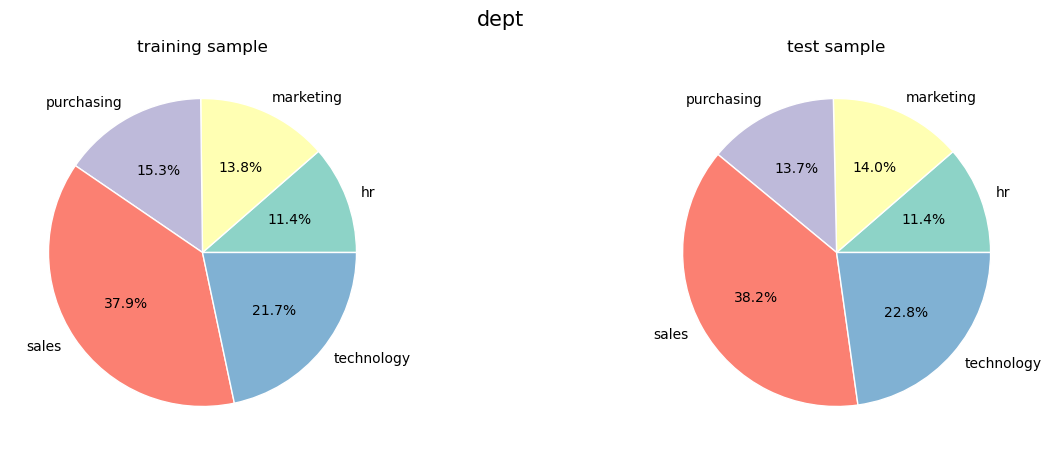

In [25]:
pie_chart('dept')

Сотрудники компании работают в 5 отделах: наибольшее количество (чуть в менее 40 процентов) в отделе продаж, чуть более 20 процентов в техническом отделе, примерно одинаковое количество сотрудников работают в отделе закупок и маркетинговом отделе, на последнем месте по количеству сотрудников  - HR отдел (11.4 процента). Распределения в тренировочной и тестовой выборках почти не отличаются.  

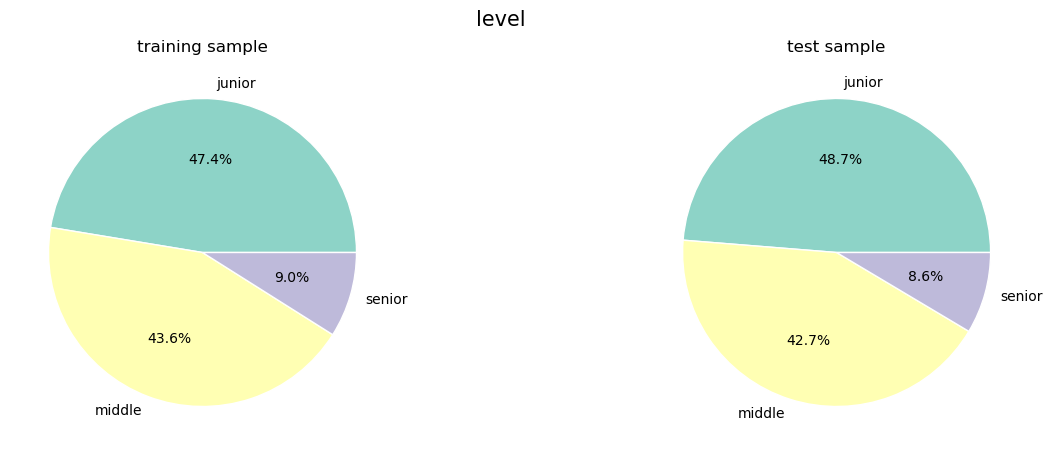

In [26]:
pie_chart('level')

Распределения в тренировочной и тестовой выборках также почти не отличаются. Распределение сотрудников по уровню занимаемой должности демонстрирует преобладание младших специалистов: примерно половина команды имеют уровень `junior`, чуть больше 40 процентов работают на позиции `middle`, а доля `senior-специалистов` меньше 10 процентов.

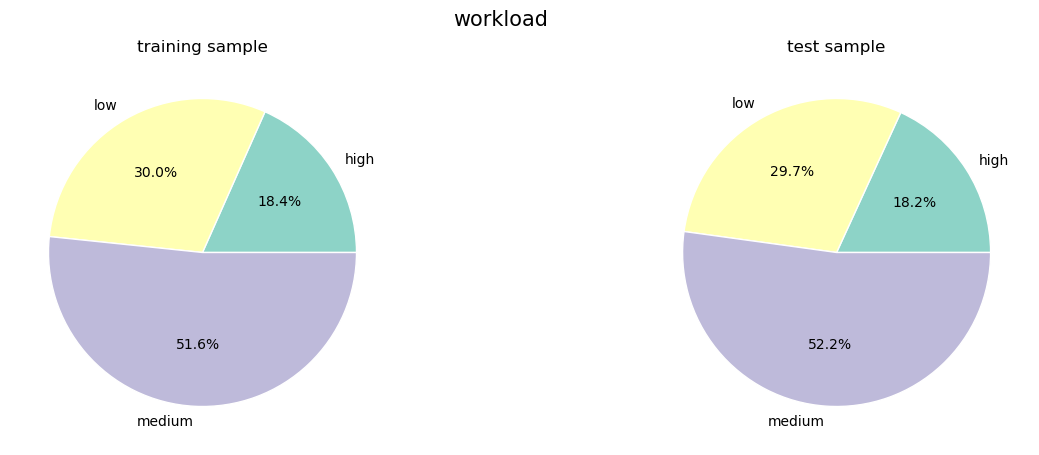

In [27]:
pie_chart('workload')

Распределение рабочей нагрузки следущее: около 50 процентов специалистов имеют среднюю занятость, 30 процентов - низкую и примерно 20 процентов - высокую занятость.

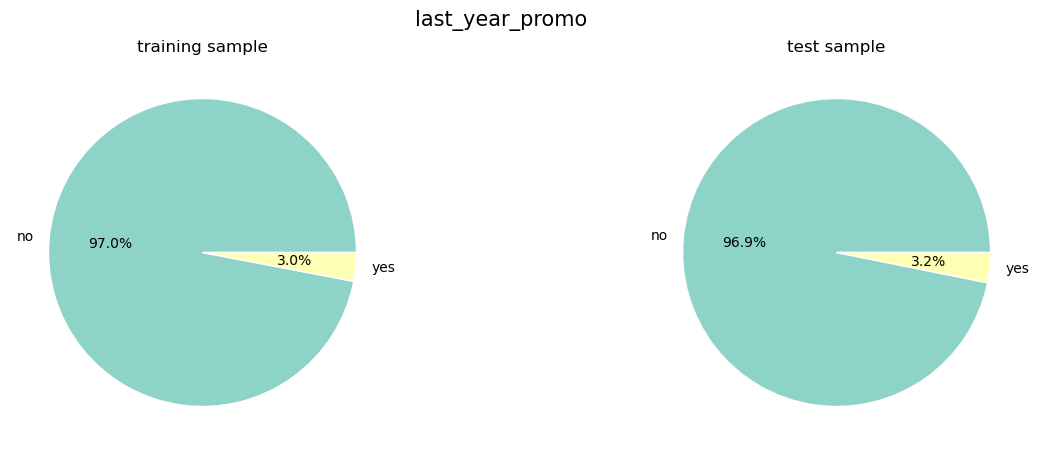

In [28]:
pie_chart('last_year_promo')

Только 3 процента сотрудников получили повышения за последний год.

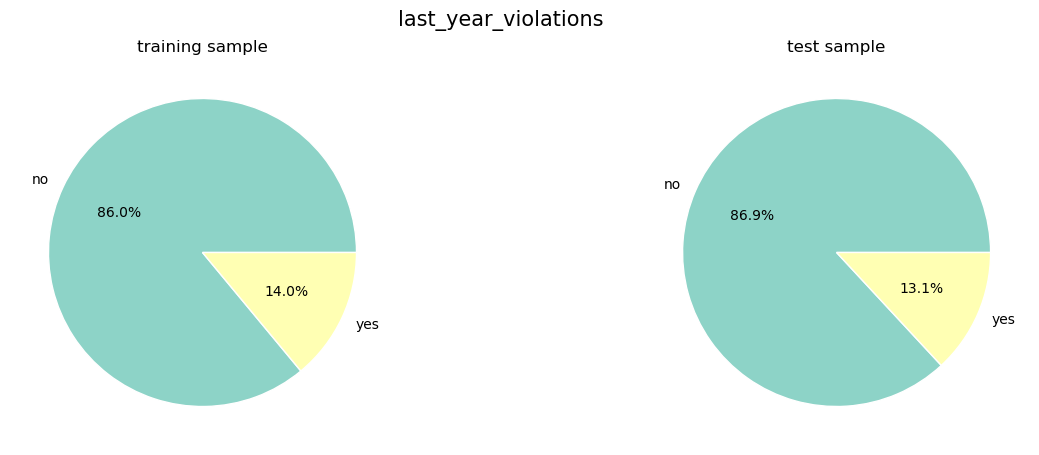

In [29]:
pie_chart('last_year_violations')

Около 14 процентов сотрудников нарушали трудовой договор за последний год. 

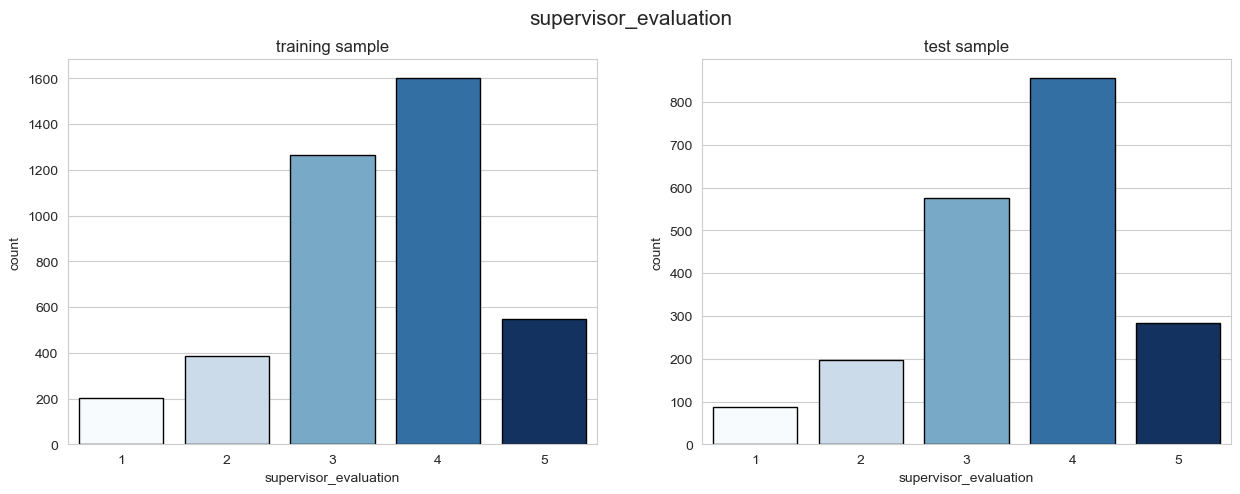

In [30]:
countplot('supervisor_evaluation')

Наиболее часто встречается оценка 4, далее - 3 и 5. Оценки 1 и 2 встречаются реже.

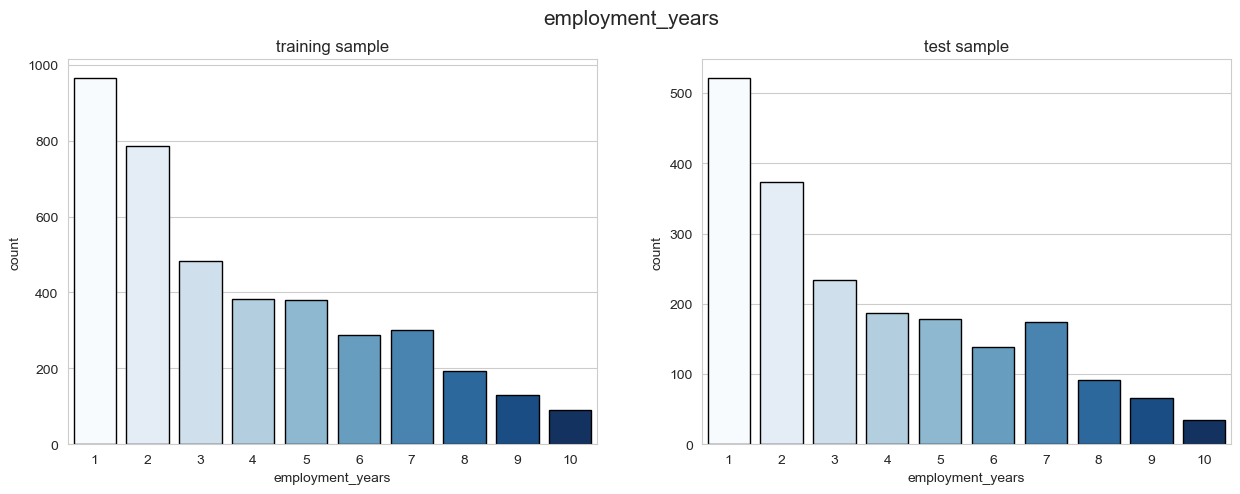

In [31]:
countplot('employment_years')

Распределение стажа скошено вправо: больше всего сотрудников с небольшим стажем, а с увеличением числа лет наблюдений становится меньше. Максимальное количество лет работы в компании - 10 лет. 

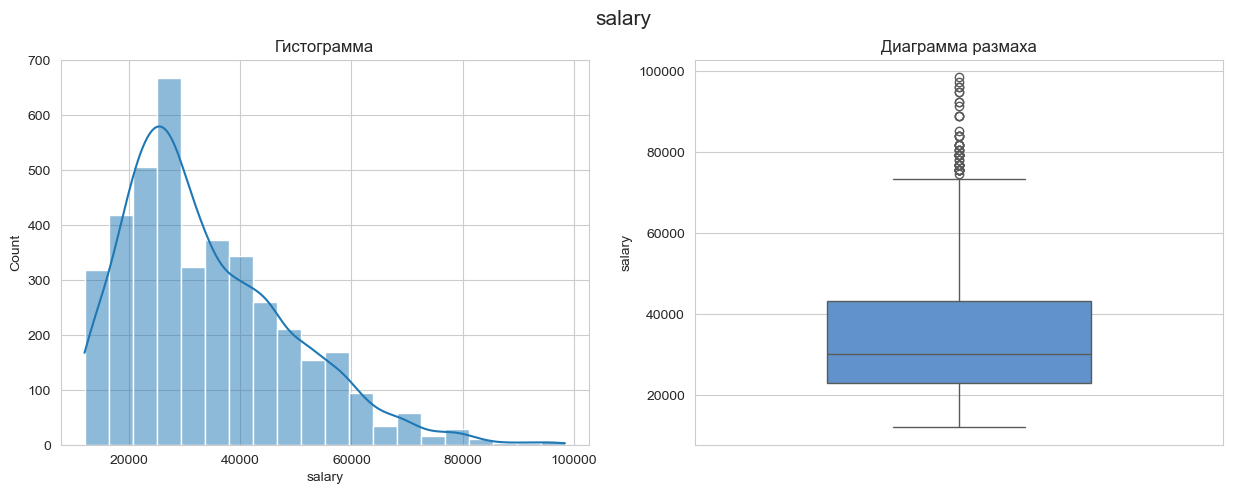

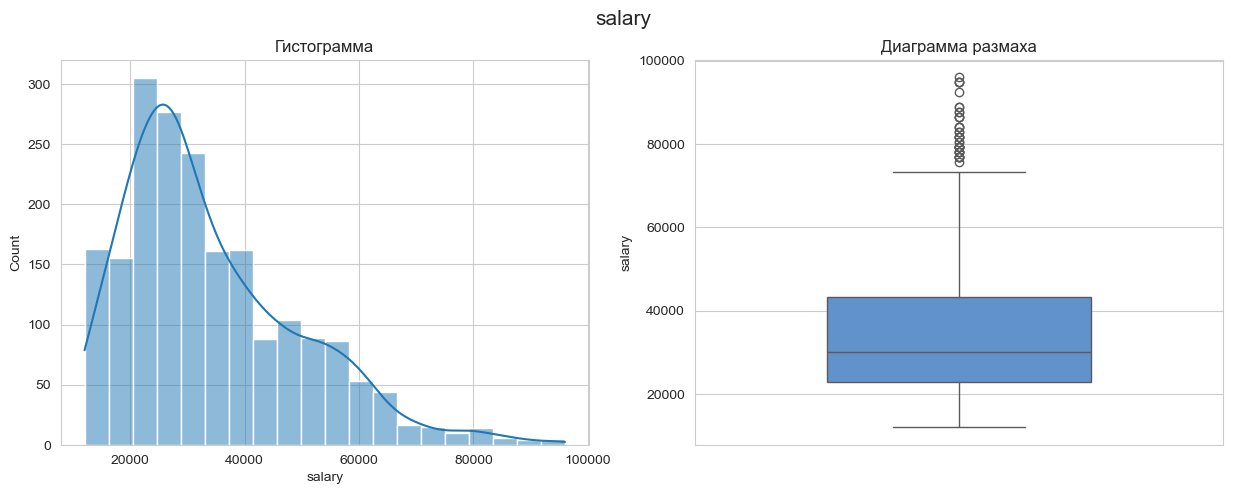

In [32]:
# для тренировочной выборки
hist_and_boxplot('salary', df_train)
# для тестовой выборки
hist_and_boxplot('salary', df_test_features)

Распределение зарплаты имеет правую асимметрию: основная масса значений сосредоточена в нижней и средней части диапазона, при этом встречаются сотрудники с существенно более высокой зарплатой. Медианная зарплата - 30 тысяч, средняя - около 33.9 тысяч.

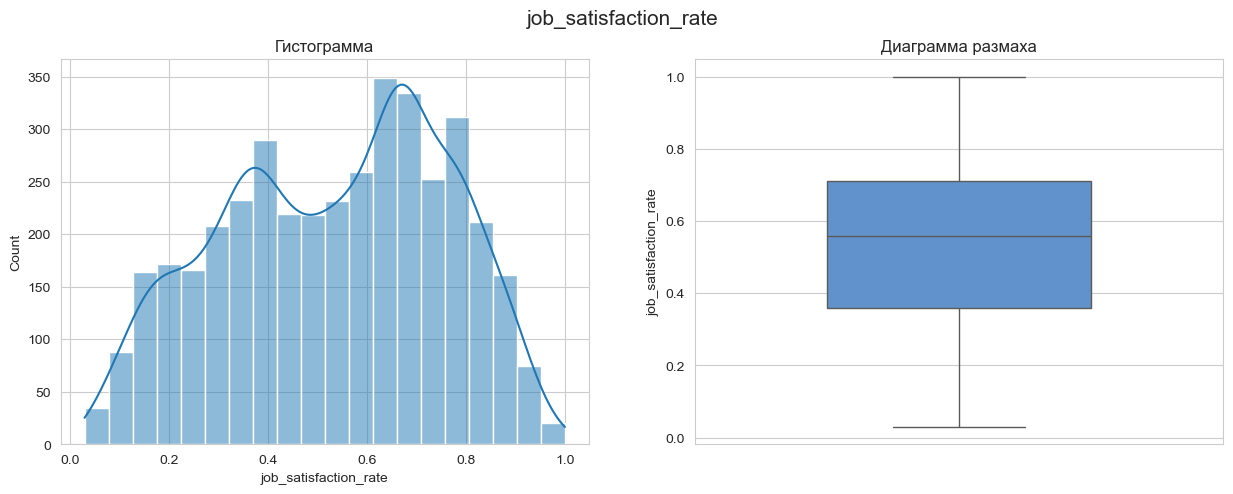

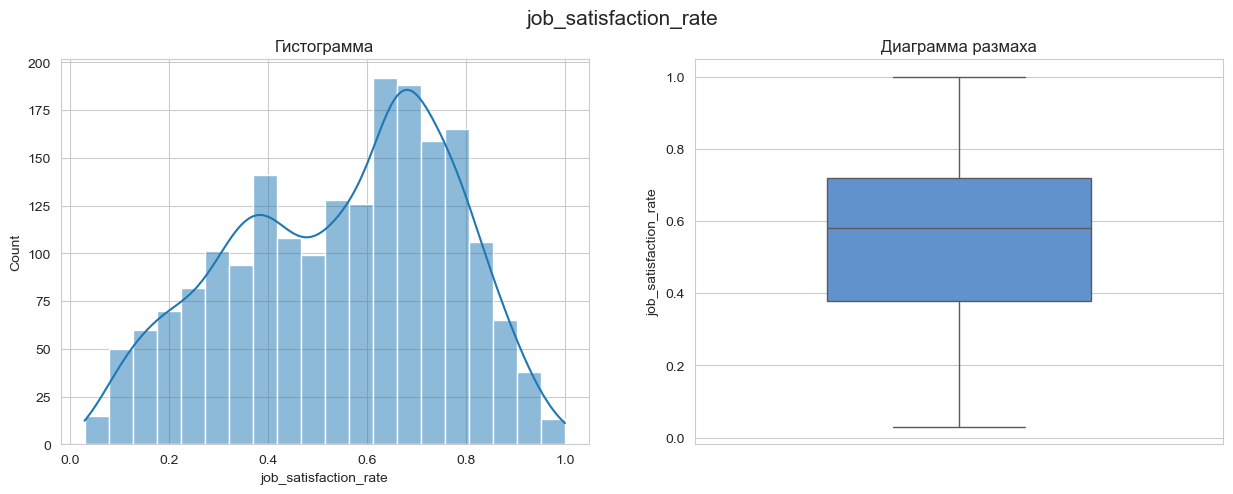

In [33]:
# для тренировочной выборки
hist_and_boxplot('job_satisfaction_rate', df_train)
# для тестовой выборки
hist_and_boxplot('job_satisfaction_rate', df_test_target)

Распределения сотрудников по уровню удовлетворенности работой в компании для тестовой и тренировочной выборки похожи: центральные 50% значений `job_satisfaction_rate` находятся примерно в диапазоне 0.36-0.71, медиана составляет 0.56. В выборке присутствуют как низкие, так и значения, близкие к максимальному уровню 1.

**Выводы:** 

* В обучающей и тестовой выборках распределения входных признаков в целом близки; выраженных различий по рассмотренным одномерным распределениям не обнаружено.

* В компании представлены пять подразделений, наиболее многочисленным является отдел продаж. Среди сотрудников преобладают уровни `junior` и `middle`; доля `senior` существенно меньше.

* Наиболее распространён средний уровень рабочей нагрузки. Повышение за последний год встречается редко, нарушения трудового договора также наблюдаются у меньшей части сотрудников.

* Наиболее частая оценка руководителя - 4. Стаж сотрудников составляет от 1 до 10 лет, при этом сотрудники с небольшим стажем встречаются чаще.

* Зарплата в обучающей выборке варьируется от 12000 до 9 400, медиана составляет 30000. Распределение имеет правую асимметрию.

* Целевая переменная `job_satisfaction_rate` принимает значения от 0.03 до 1.00, медиана составляет 0.56; центральные 50% наблюдений находятся в диапазоне 0.36–0.71.

### Корреляционный анализ данных

Построим матрицу корреляции

In [34]:
# непрерывные признаки
interval_cols= ['salary', 'job_satisfaction_rate']

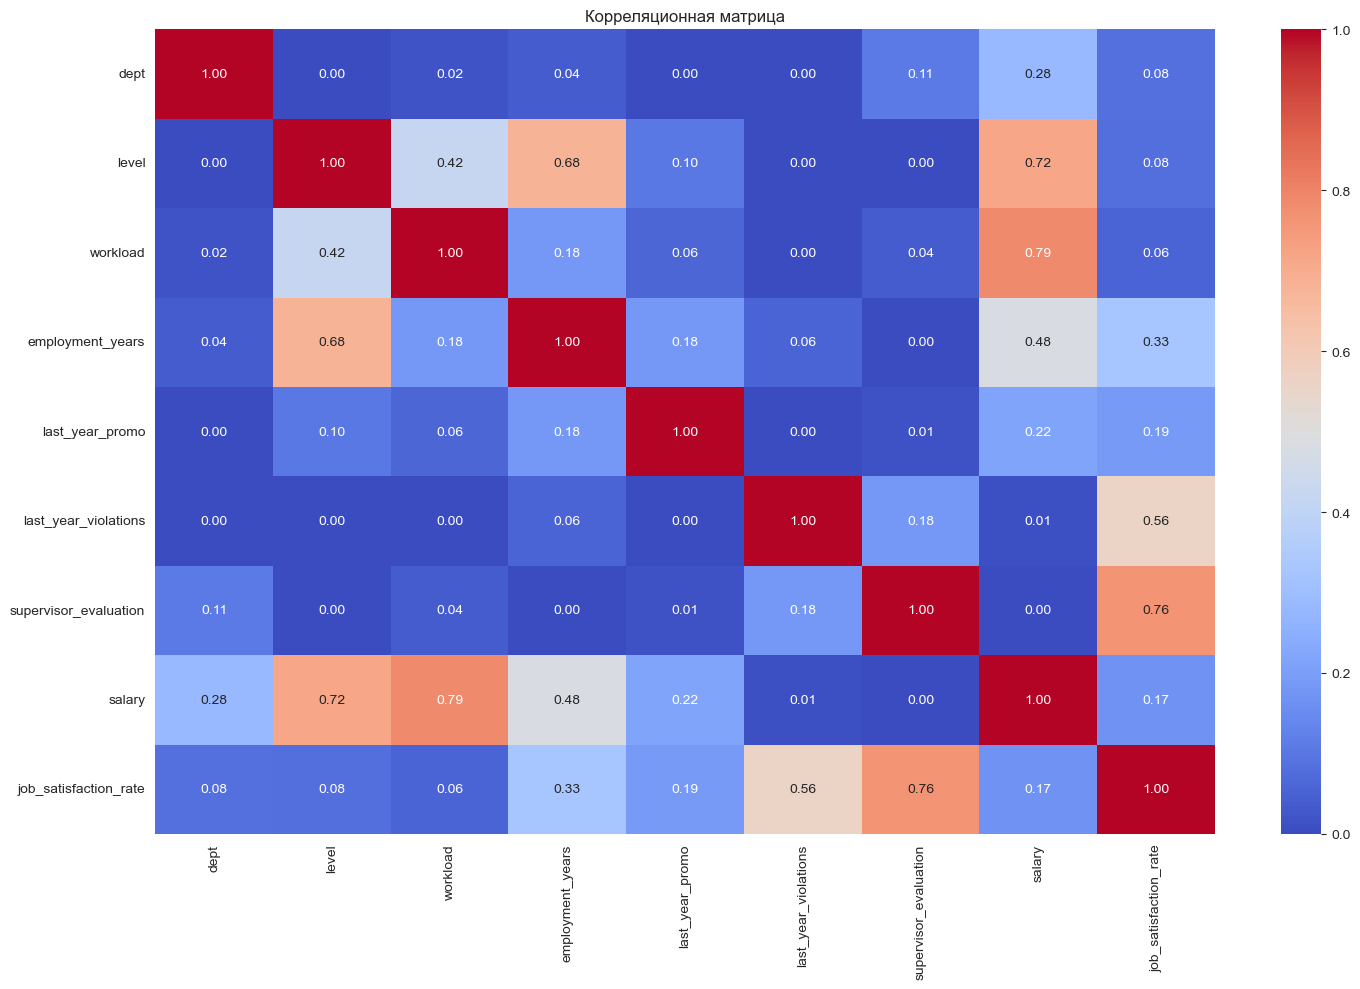

In [35]:
phik_corr = df_train.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

По матрице наиболее выраженная связь целевой переменной `job_satisfaction_rate` наблюдается с `supervisor_evaluation`; также заметна связь с `last_year_violations`.

Между `salary`, `level`, `employment_years` и `workload` наблюдаются выраженные взаимосвязи. Эти признаки описывают разные характеристики сотрудника, поэтому удалять их не будем. Их полезность будет оцениваться в составе моделей на кросс-валидации.

Аналогично проведем анализ корреляции для тестовой выборки. Объединим тестовые данные по `id` и проверим размер полученной выборки.

In [36]:
df_test = df_test_features.merge(df_test_target, on='id', how='left')
print(f'Размер df_test: {df_test.shape}')
df_test.head()

Размер df_test: (2000, 10)


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79
1,686555,hr,junior,medium,1,no,no,4,30000,0.72
2,467458,sales,middle,low,5,no,no,4,19200,0.64
3,418655,sales,middle,low,6,no,no,4,19200,0.60
4,789145,hr,middle,medium,5,no,no,5,40800,0.75


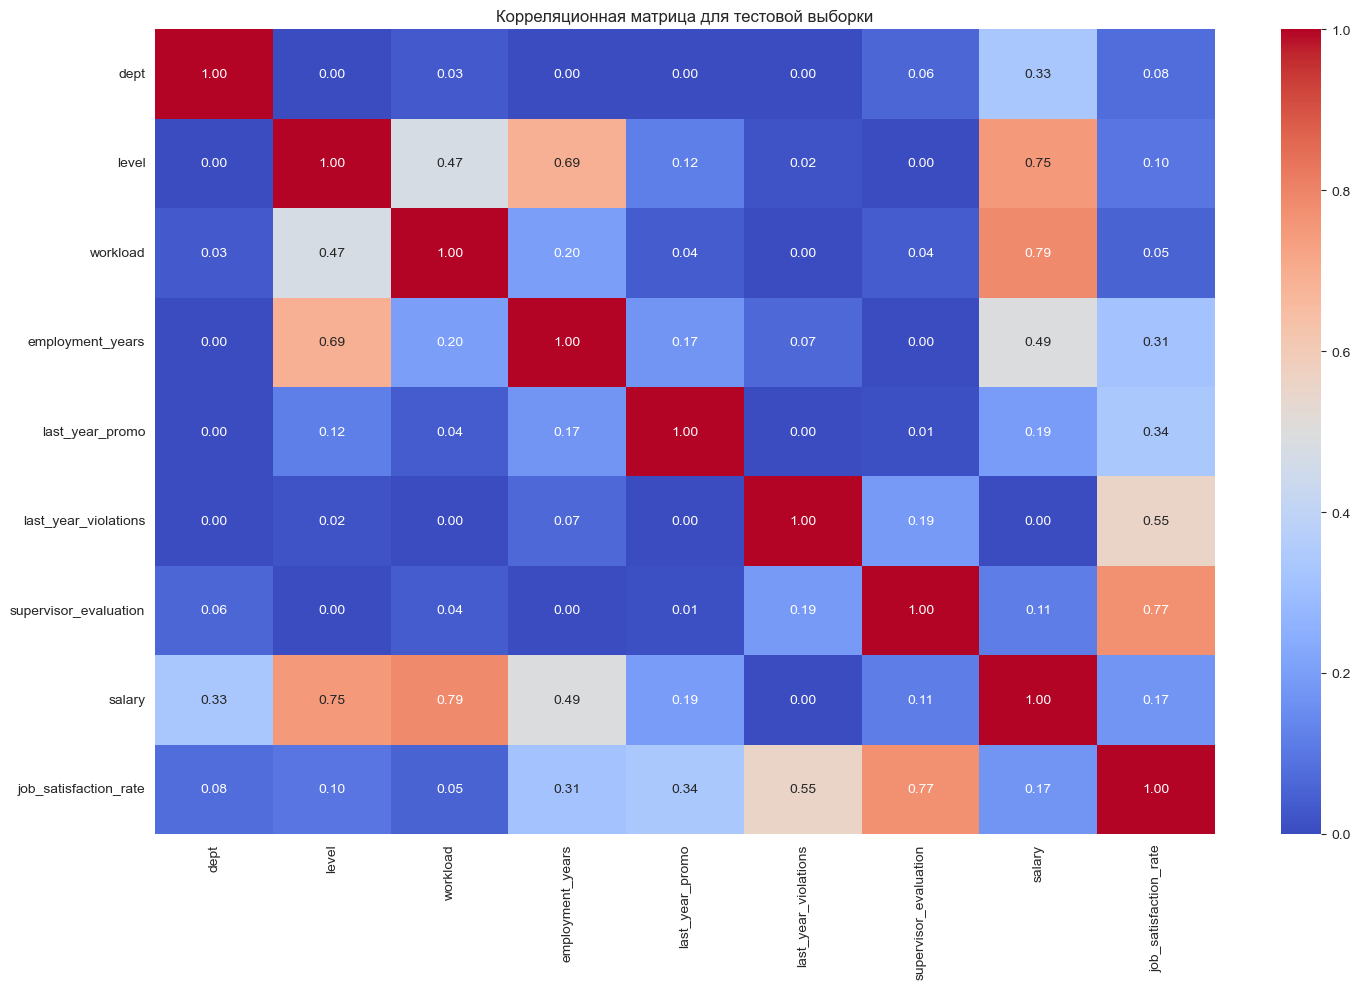

In [37]:
phik_matrix_test = df_test.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix_test, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для тестовой выборки")
plt.tight_layout()
plt.show()

Видно, что для тренировочной выборки корреляционная матрица почти не отличается от матрицы тренировочной выборки. Связь между признаками аналогичная.

**Выводы:**
Матрица корреляции показывает, что наиболее выраженная связь `job_satisfaction_rate` наблюдается с `supervisor_evaluation`; также присутствует связь с `last_year_violations`.
Среди входных признаков заметны взаимосвязи между `salary`, `level`, `employment_years` и `workload`. Матрица отражает статистическую связь между признаками и не устанавливает причинно-следственные зависимости.

На этапе подготовки данных необходимо:
* обработать пропуски,
* закодировать категориальные признаки,
* исключить `id` из набора признаков,
* при необходимости масштабировать числовые признаки для моделей, чувствительных к масштабу.

### Подготовка данных

In [38]:
# скопируем данные из второго датафрейма для дальнейшего использования
df_test_features_2 = df_test_features.copy()
df_test_features_2.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


Для дальнейшего удобства работы с данными установим колонку id в качестве индекса датафрейма. 

In [39]:
# скопируем данные для дальнейшего использования
df_train_copy = df_train.copy()

# устанавливаем столбец 'id' в качестве индекса
df_train = df_train.set_index('id')
df_train.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


Проверим данные на наличие новых дубликатов.

In [40]:
print(f'В тренировочной выборке {df_train.duplicated().sum()} дубликатов') 
print(f'Доля дубликатов в тренировочной выборке: {(df_train.duplicated().sum()/len(df_train)).round(2)}') 

В тренировочной выборке 245 дубликатов
Доля дубликатов в тренировочной выборке: 0.06


В данных появились явные дубликаты, но их немного, поэтому удалим дубликаты. 

In [41]:
df_train = df_train.drop_duplicates(keep='first')
print(f'В тренировочной выборке стало {df_train.duplicated().sum()} дубликатов') 
print(f'Длина датафрейма после удаления части данных стала {len(df_train)}')

В тренировочной выборке стало 0 дубликатов
Длина датафрейма после удаления части данных стала 3755


Создадим пайплайн для подготовки данных

In [42]:
# определяем целевой и входные признаки
X_train = df_train.drop(['job_satisfaction_rate'], axis=1)
y_train = df_train['job_satisfaction_rate']

In [43]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level','workload']
num_columns = ['employment_years', 'salary','supervisor_evaluation']

In [44]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ]
)

In [45]:
# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(categories=[
                               ['junior', 'middle', 'senior'],
                               ['low', 'medium', 'high']
                
                          ],
                          handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [46]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

**Вывод**: для моделирования выделены входные признаки и целевая переменная; `id` исключён из признаков и сохраняется только как индекс. Категориальные признаки разделены на номинальные и порядковые. Пропуски, кодирование категорий и масштабирование числовых признаков выполняются внутри `ColumnTransformer`, что позволяет обучать преобразования только на соответствующих обучающих данных при кросс-валидации.

### Обучение моделей

Выбор модели необходимо сделать на основе новой метрики — `SMAPE` (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»). С помощью функции `make_scorer` создадим необходимую метрику. 

Успешность модели будет определяться по следующему критерию: значение `SMAPE` на тестовой выборке должно быть не более 15%. 

In [47]:
# функция для расчета метрики SMAPE
def smape(y_true, y_pred):
    metric = 100 / len(y_true) * np.sum(2 * np.abs(y_true-y_pred) / (np.abs(y_pred) + np.abs(y_true)))
    return metric

smape_scorer = make_scorer(smape, greater_is_better=False)

In [48]:
# задаем фиксированное значение для random_state
RANDOM_STATE = 42
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

In [49]:
param_grid = [{'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
               'models__max_depth': range(2, 16),
               'models__max_features': range(2,11),
               'models__min_samples_split':range(2,11),
               'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']},

             {'models': [LinearRegression( )],
              'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']}]

In [50]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    n_iter=30,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1)

# обучение модели
randomized_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [DecisionTreeR...ndom_state=42)], 'models__max_depth': range(2, 16), 'models__max_features': range(2, 11), 'models__min_samples_split': range(2, 11), ...}, {'models': [LinearRegression()], 'preprocessor__num': [StandardScaler(), MinMaxScaler(), ...]}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(s...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refit

In [51]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика SMAPE на кросс-валидации:', round(-randomized_search.best_score_, 2))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                            

Лучшей моделью оказалась DecisionTreeRegressor с max_depth=14, max_features=8 и min_samples_split=6. Проверим метрику на тестовой выборке

In [52]:
X_test = df_test_features.set_index('id').sort_index()
y_test = df_test_target.set_index('id').sort_index()

In [53]:
y_predict = randomized_search.predict(X_test)

In [54]:
print(f'Метрика SMAPE на тестовой выборке:',smape(np.array(y_test['job_satisfaction_rate']), y_predict).round(2))

Метрика SMAPE на тестовой выборке: 14.09


Метрика `SMAPE` на тестовой выборке получилась меньше 15 процентов. 

Проверим модель на адекватность и посчитаем метрику для константной DummyRegressor.

In [55]:
# создание и обучение модели DummyRegressor
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

# предсказание на тестовых данных
dummy_model_predict = dummy_model.predict(X_test)

# посчитаем и выведем метрику SMAPE
dummy_smape = smape(np.array(y_test['job_satisfaction_rate']), dummy_model_predict)
print('SMAPE =', round(dummy_smape, 2))

SMAPE = 38.26


Получилось, что выбранная лучшая модель лучше константной. Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP

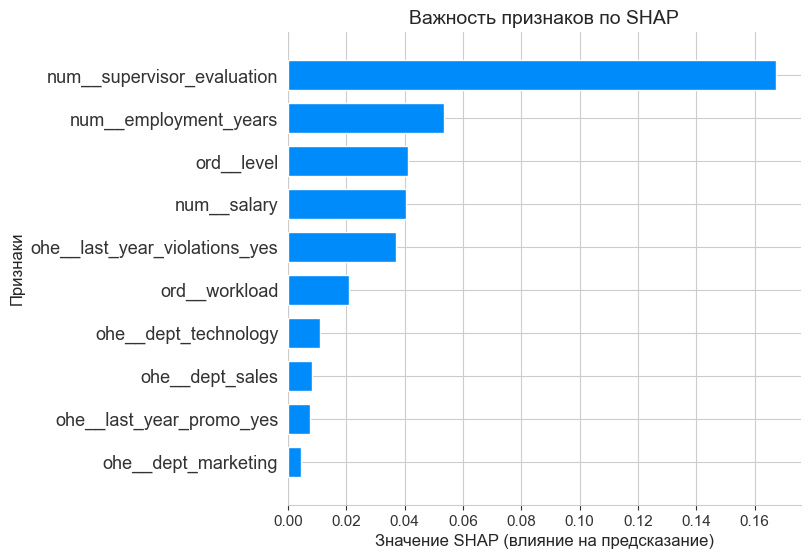

In [56]:
best_pipeline = randomized_search.best_estimator_

preprocessor = best_pipeline.named_steps['preprocessor']
model = best_pipeline.named_steps['models']

X_train_transformed = preprocessor.transform(X_train)

X_train_shap = pd.DataFrame(
    X_train_transformed,
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_shap)

shap.summary_plot(shap_values, X_train_shap, plot_type="bar", show=False, max_display=10)

plt.xlabel('Значение SHAP (влияние на предсказание)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Важность признаков по SHAP', fontsize=14)
plt.show()

SHAP-анализ показал, что наибольший вклад в прогноз модели вносят:
* оценка сотрудника руководителем (`supervisor_evaluation`);
* продолжительность работы в компании (`employment_years`);
* уровень должности (`level`);
* размер заработной платы (`salary`).

**Выводы:** 
* Обучены 2 модели: `LinearRegression` и `DecisionTreeRegressor`;

* Для подбора гиперпараметров использовался `RandomizedSearchCV`;

* Для оценки качества моделей выбрана метрика `SMAPE`;

 На отложенной тестовой выборке модель получила `SMAPE = 14.09%`, что удовлетворяет установленному в задаче критерию SMAPE ≤ 15%

### Выводы

Для прогнозирования уровня удовлетворённости сотрудников были сравнены модели `LinearRegression` и `DecisionTreeRegressor`. Предобработка данных - заполнение пропусков, кодирование категориальных признаков и масштабирование при необходимости - выполнялась внутри единого пайплайна.

Подбор гиперпараметров проводился с помощью `RandomizedSearchCV` и 5-кратной кросс-валидации по метрике `SMAPE`. Лучший результат среди рассмотренных конфигураций показал `DecisionTreeRegressor` с max_depth=14, max_features=8 и min_samples_split=6.

Средний `SMAPE` на кросс-валидации составил 15.37%. На отложенной тестовой выборке модель получила `SMAPE = 14.09%`, что удовлетворяет установленному в задаче критерию SMAPE ≤ 15%. Для сравнения константный `DummyRegressor` показал SMAPE = 38.26%.

По результатам SHAP-анализа наибольший вклад в прогноз модели вносят оценка сотрудника руководителем, продолжительность работы в компании, уровень должности и размер заработной платы. SHAP отражает поведение модели и не устанавливает причинно-следственные связи между этими признаками и удовлетворённостью сотрудников.


## Задача 2: предсказание увольнения сотрудника из компании

### Загрузка данных

Загрузим новые данные. Тестовая выборка входных признаков осталась прежней 

In [57]:
path = 'datasets'

if os.path.exists(path):
    df_quit = pd.read_csv(os.path.join(path, 'train_quit.csv'))
    df_test_quit = pd.read_csv(os.path.join(path, 'test_target_quit.csv'))
else:
    raise FileNotFoundError(
        f'Папка с данными не найдена: {path}'
    )

In [58]:
# выводим общую информацию и первые строки нового датафрейма
df_quit.info()
df_quit.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


Во новой тренировочной используется тот же набор входных признаков, что и в первой; отличается только целевая переменная: вместо `job_satisfaction_rate` предсказывается `quit`. Всего 4000 строк и 10 столбцов, пропущенных значений нет, типы данных соответствуют характеру признаков.

In [59]:
df_test_quit.info()
df_test_quit.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


Целевым признаком теперь является информация от том уволился ли сотрудник из компании `quit`. В тестовой выборке 2000 строк, пропусков нет, типы данных соответствуют характеру признаков.

**Вывод:** Загружены обучающая выборка для задачи классификации и тестовая целевая переменная. В `df_quit` содержатся 4000 наблюдений, 9 входных признаков и бинарный целевой признак `quit`; пропущенных значений нет. `df_test_quit` содержит `id` сотрудников и соответствующий целевой признак для 2000 наблюдений.

Состав входных признаков во второй задаче совпадает с первой задачей: используются те же характеристики сотрудников, а вместо целевой переменной `job_satisfaction_rate` используется целевой признак `quit`.

Для тестовой выборки используются ранее загруженные входные признаки `df_test_features_2`. Перед финальной оценкой тестовые признаки и целевая переменная `quit` будут сопоставлены по `id`.

###  Предобработка данных

Изучим новые данные на наличие пропусков (еще раз), явных и неявных дубликатов.

In [60]:
# суммарное количество пропусков
print(f'В датафрейме df_quit {df_quit.isna().sum().sum()} пропусков')
print(f'В датафрейме df_test_quit {df_test_quit.isna().sum().sum()} пропусков')

В датафрейме df_quit 0 пропусков
В датафрейме df_test_quit 0 пропусков


In [61]:
# выведем суммарное количество явных дубликатов 
print(f'В тренировочной выборке {df_quit.duplicated().sum()} дубликатов') 
print(f'В тестовой выборке с целевым признаком {df_test_quit.duplicated().sum()} дубликатов')

В тренировочной выборке 0 дубликатов
В тестовой выборке с целевым признаком 0 дубликатов


In [62]:
# выведем суммарное количество дубликатов в столбце id 
print(f'В столбце "id" первого датафрейма {df_quit.duplicated(subset="id").sum()} дубликатов') 
print(f'В столюце "id" третьего датафрейма {df_test_quit.duplicated(subset="id").sum()} дубликатов')

В столбце "id" первого датафрейма 0 дубликатов
В столюце "id" третьего датафрейма 0 дубликатов


In [63]:
# уникальные значения в категориальных столбцах
cat_cols_quit = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations', 'quit']
for col in cat_cols_quit:
    print(f'В столбце "{col}" следующие уникальные значения: {df_quit[col].unique()}')

В столбце "dept" следующие уникальные значения: ['sales' 'purchasing' 'marketing' 'technology' 'hr']
В столбце "level" следующие уникальные значения: ['middle' 'junior' 'sinior']
В столбце "workload" следующие уникальные значения: ['high' 'medium' 'low']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']
В столбце "quit" следующие уникальные значения: ['no' 'yes']


Некорректных категорий, кроме опечатки `sinior`, не обнаружено. Исправим её на `senior`.

In [64]:
df_quit['level'] = df_quit['level'].replace('sinior', 'senior')

In [65]:
print('После преобразований в датафрейме df_ quit:')
for col in cat_cols_quit:
    print(f'В столбце "{col}" следующие уникальные значения: {df_quit[col].unique()}')

После преобразований в датафрейме df_ quit:
В столбце "dept" следующие уникальные значения: ['sales' 'purchasing' 'marketing' 'technology' 'hr']
В столбце "level" следующие уникальные значения: ['middle' 'junior' 'senior']
В столбце "workload" следующие уникальные значения: ['high' 'medium' 'low']
В столбце "last_year_promo" следующие уникальные значения: ['no' 'yes']
В столбце "last_year_violations" следующие уникальные значения: ['no' 'yes']
В столбце "quit" следующие уникальные значения: ['no' 'yes']


**Выводы:** в новых таблицах пропущенные значения и явные дубликаты отсутствуют, значения `id` уникальны. При проверке категориальных значений обнаружена опечатка `sinior`, которая исправлена на `senior`. Целевая переменная `quit` содержит два класса: `yes` и `no`.

В тестовых входных признаках `df_test_features_2` ранее были обнаружены пропуски; они будут обработаны внутри пайплайна на этапе подготовки данных.

Данные готовы к исследовательскому анализу.

### Исследовательский анализ данных

#### ИАД новой тренировочной выборки

In [66]:
# выведем сводную статистическую информацию 
num_cols_quit = ['employment_years', 'supervisor_evaluation', 'salary']

df_quit[num_cols_quit].describe()

,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000
mean,3.701500,3.474750,33805.800000
std,2.541852,1.004049,15152.415163
min,1.000000,1.000000,12000.000000
25%,2.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000


Числовые признаки находятся в правдоподобных диапазонах: стаж - от 1 до 10 лет, оценка руководителя - от 1 до 5, зарплата - от 12 000 до 96 000. Явных некорректных значений не обнаружено.

Построим круговые диаграммы для категориальных признаков.

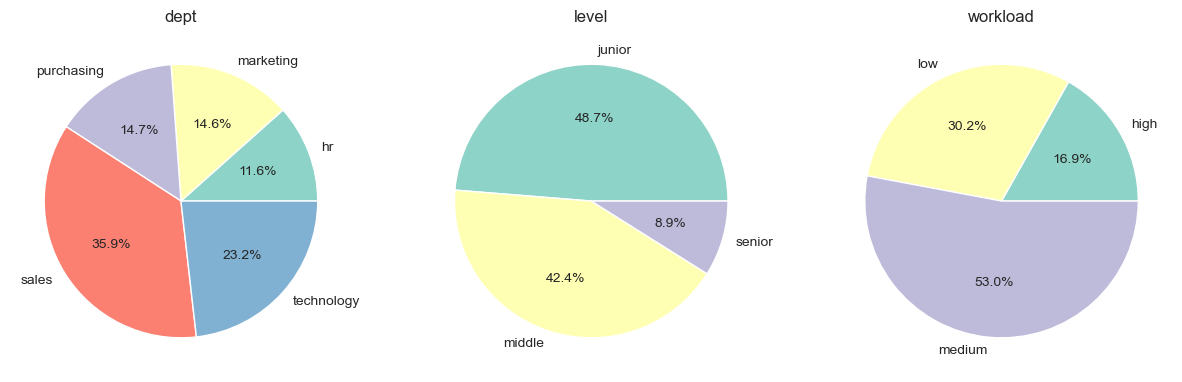

In [67]:
colors = plt.cm.Set3(range(len(df_quit['dept'].unique()))) # используем палитру Set3
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1) 
df_quit.groupby('dept')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('dept')
plt.ylabel('')  
plt.subplot(1, 3, 2) 
df_quit.groupby('level')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('level')
plt.ylabel('')
plt.subplot(1, 3, 3) 
df_quit.groupby('workload')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('workload')
plt.ylabel('')  
plt.show()

В новой выборке также сотрудники распределены по 5 отделам. Около 36 процентов работают в отделе  продаж, примерно 23 в техотделе, примерно одинаковое количество сотрудников работают в отделе закупок и маркетинговом отделе, на последнем месте по количеству сотрудников  - HR отдел.

Примерно половина из всех сотрудников имеют уровень junior, менее 10 процентов имеют статус `senior`.

Средний уровень загруженности у 53 процентов сотрудников, низкий - у 30% и высокий у примерно 17%.

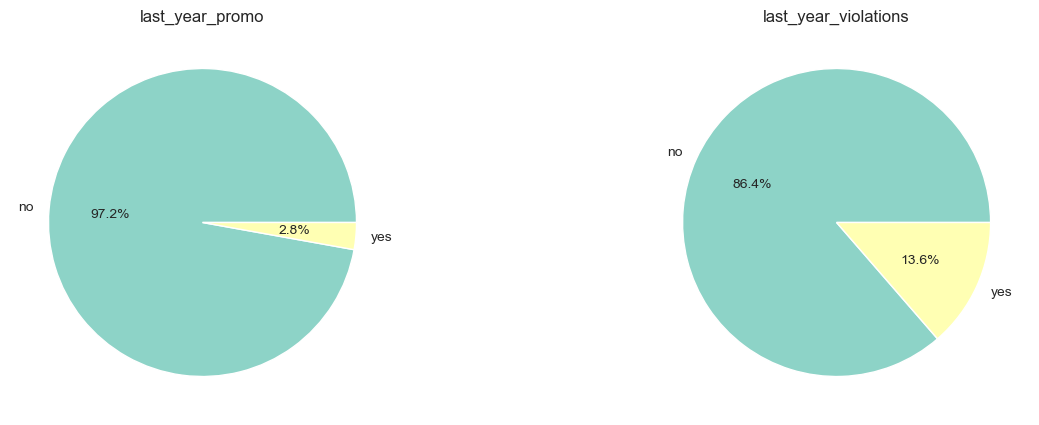

In [68]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1) 
df_quit.groupby('last_year_promo')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('last_year_promo')
plt.ylabel('')  
plt.subplot(1, 2, 2) 
df_quit.groupby('last_year_violations')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                                   wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('last_year_violations')
plt.ylabel('')
plt.show()

За последний год около трех процентов сотрудников получили повышение и около 14 нарушили ТД.

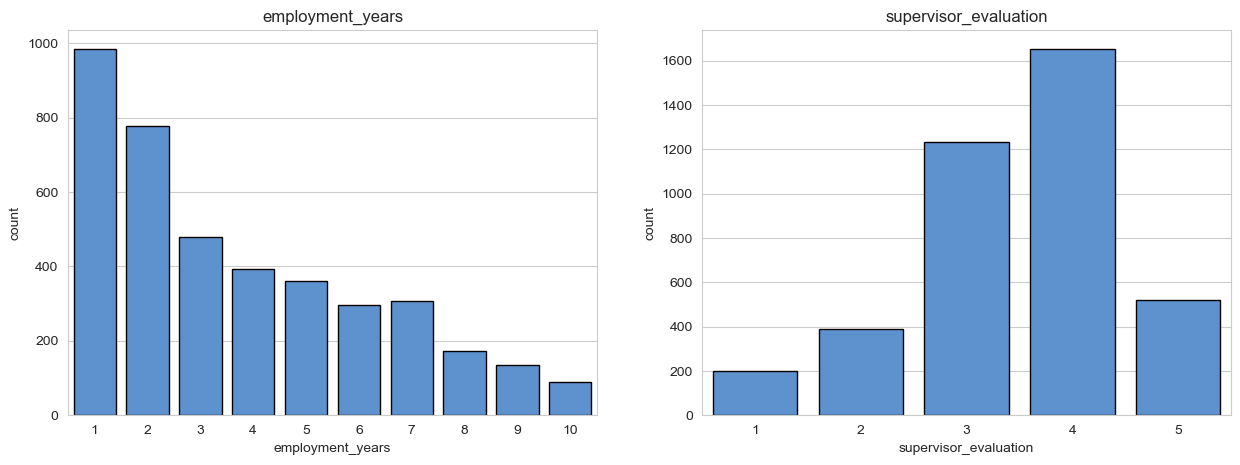

In [69]:
sns.set_style('whitegrid')
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1) 
sns.countplot(x='employment_years',  data=df_quit, color='#4a90e2', edgecolor='black')
plt.title('employment_years')
plt.subplot(1, 2, 2) 
sns.countplot(x='supervisor_evaluation', data=df_quit, color='#4a90e2', edgecolor='black')
plt.title('supervisor_evaluation')
plt.show()

Наибольшее число работников имеют стаж 1 год, далее количество сотрудников уменьшается с ростом стажа. Максимальный стаж работы в компании - 10 лет.

Наиболее часто встречается оценка 4, затем 3 и 5; оценки 1 и 2 наблюдаются реже.

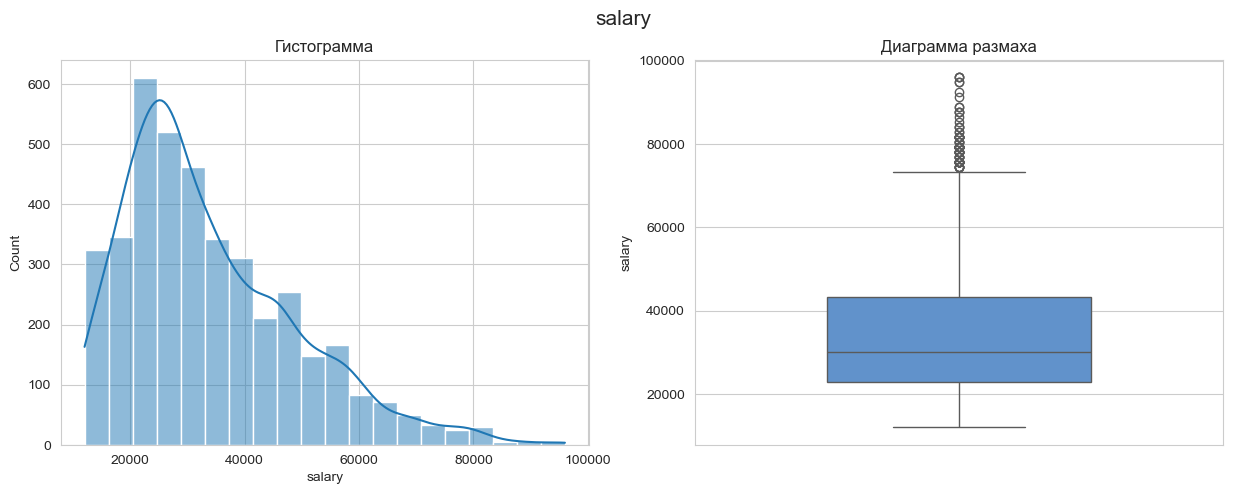

In [70]:
# для тренировочной выборки
hist_and_boxplot('salary', df_quit)

Распределение зарплаты имеет правую асимметрию. Медианная зарплата составляет 30000, средняя - около 33806. Большая часть значений сосредоточена в нижней и средней части диапазона, при этом встречаются зарплаты до 96000.

#### Анализ портрета уволенного сотрудника

Посмотрим как соотносятся уволившиеся/уволенные сотрудники и сотрудники работающие в компании  

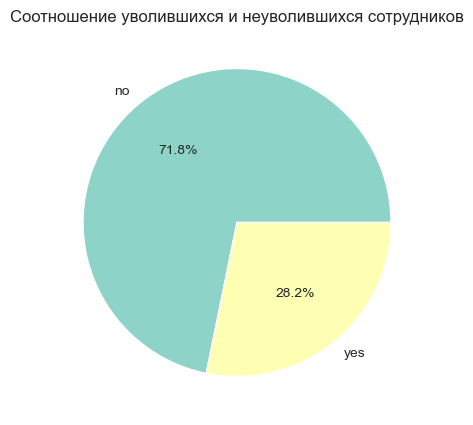

In [71]:
colors = plt.cm.Set3(range(len(df_quit['quit'].unique()))) # используем палитру Set3
plt.figure(figsize=(15, 5))
df_quit.groupby('quit')['id'].count().plot(kind='pie', colors=colors, autopct='%1.1f%%', \
                                          wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
plt.title('Соотношение уволившихся и неуволившихся сотрудников')
plt.ylabel('')  
plt.show()

Доля сотрудников, покинувших компанию, составляет около 28%, оставшихся - около 72%. Классы несбалансированы, поэтому при моделировании важно использовать метрику, подходящую для бинарной классификации, и учитывать дисбаланс при валидации.

Для дальнейшего анализа разобъем `df_quit` на две подвыборки: уволенные и не уволенные сотрудники

In [72]:
df_quit_yes = df_quit.query('quit == "yes"')
df_quit_no = df_quit.query('quit == "no"')

Посчитаем какая доля сотрудников в зависимости от признака ушла.

In [73]:
def quit_rate_by_category(col):
    table = (
        df_quit
        .assign(quit_flag=(df_quit['quit'] == 'yes').astype(int))
        .groupby(col)['quit_flag']
        .agg(['mean', 'count'])
        .rename(columns={
            'mean': 'quit_rate',
            'count': 'employees'
        })
        .sort_values('quit_rate', ascending=False)
    )

    table['quit_rate'] *= 100
    return table

In [74]:
def plot_quit_rate(col):
    data = quit_rate_by_category(col).reset_index()

    sns.barplot(data=data, x=col, y='quit_rate', color='#4a90e2', edgecolor='black')

    plt.ylabel('Доля покинувших компанию, %')
    plt.xlabel(col)
    plt.title(f'Доля увольнений в зависимости от {col}')
    plt.show()

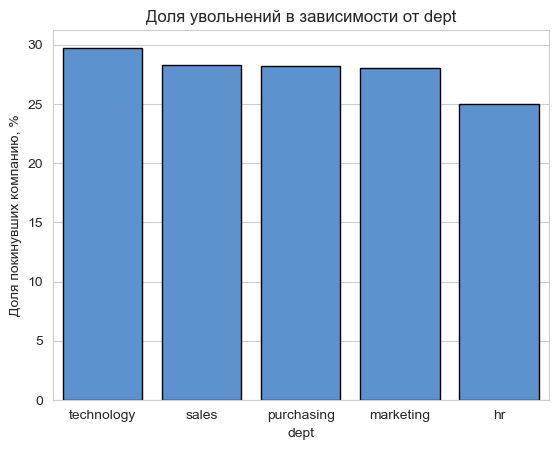

In [75]:
plot_quit_rate('dept')

Доля сотрудников, покинувших компанию, по отделам различается незначительно: максимальное значение наблюдается в отделе `technology` - около 30%, минимальное в `hr` - около 25%. Таким образом, принадлежность к конкретному отделу сама по себе не демонстрирует выраженных различий в частоте увольнений.

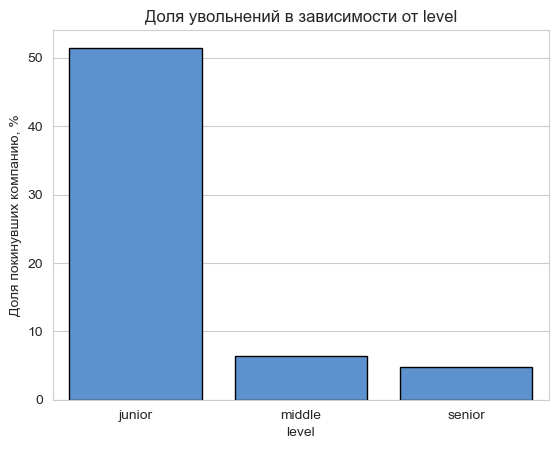

In [76]:
plot_quit_rate('level')

Доля сотрудников, покинувших компанию, значительно выше среди junior-специалистов - более 50%. Для middle и senior-специалистов доля увольнений составляет около 5%.

Таким образом, уровень должности связан с заметными различиями в частоте увольнений: сотрудники уровня `junior` покидают компанию существенно чаще, чем `middle` и `senior`.

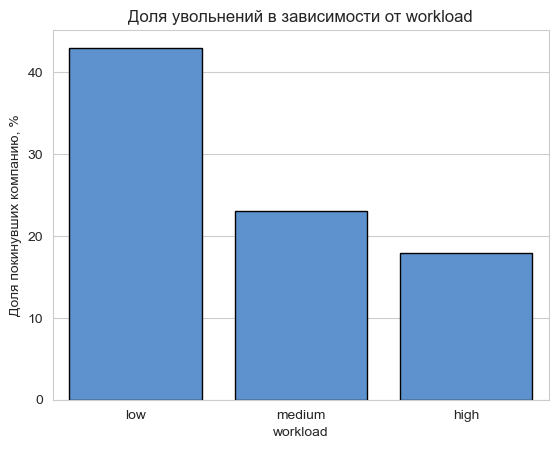

In [77]:
plot_quit_rate('workload')

Наибольшая доля сотрудников, покинувших компанию, наблюдается среди сотрудников с низкой рабочей нагрузкой - более 40%. При средней нагрузке доля увольнений составляет чуть более 20%, а при высокой - менее 20%.

Таким образом, в данной выборке более низкая рабочая нагрузка связана с более высокой частотой увольнений.

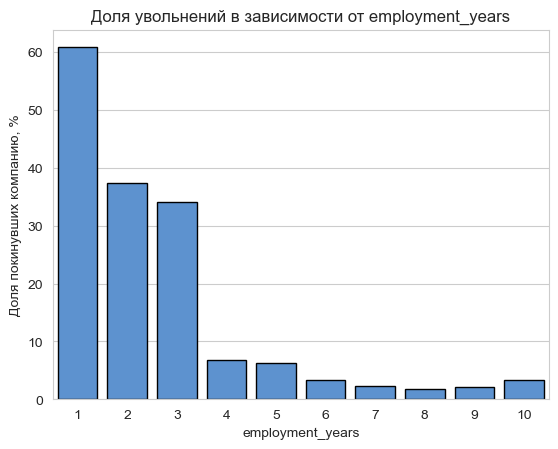

In [78]:
plot_quit_rate('employment_years')

Наибольшая доля увольнений наблюдается среди сотрудников с минимальным стажем. Около 60% сотрудников со стажем 1 год покинули компанию; среди сотрудников со стажем 2–3 года доля увольнений составляет примерно 35%. Для сотрудников, проработавших 4 года и более, этот показатель снижается до менее 10%.

Таким образом, в данной выборке меньший стаж связан с существенно более высокой частотой увольнений.

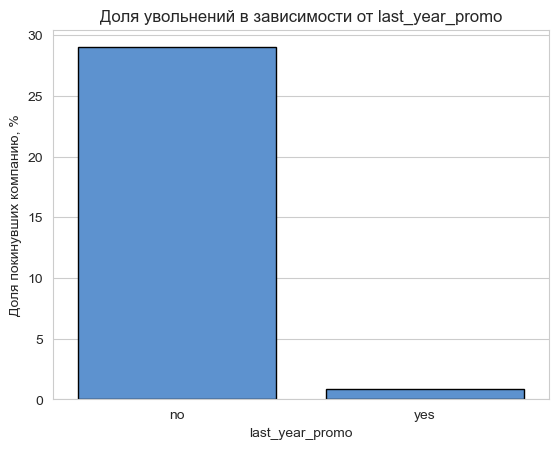

In [79]:
plot_quit_rate('last_year_promo')

Среди сотрудников, не получивших повышение за последний год, доля увольнений составляет около 30%. Среди сотрудников, получивших повышение, компания покинула лишь небольшая доля - менее 2%.

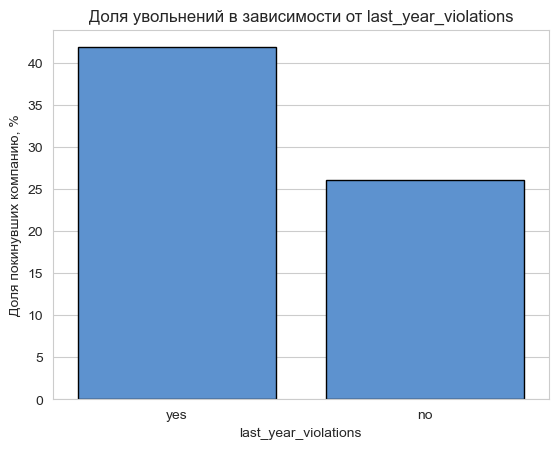

In [80]:
plot_quit_rate('last_year_violations')

Среди сотрудников, нарушавших трудовой договор за последний год, доля увольнений превышает 40%. Среди сотрудников без нарушений этот показатель составляет около 25%.

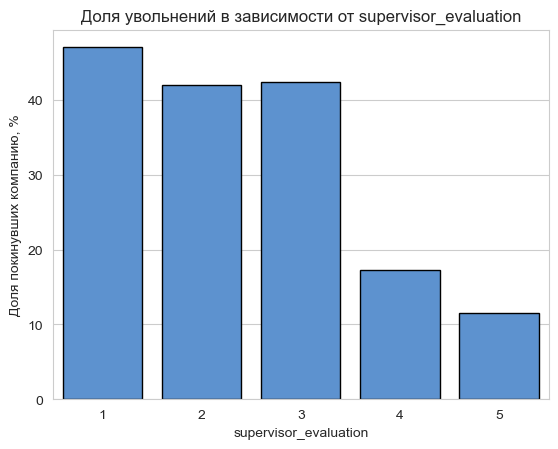

In [81]:
plot_quit_rate('supervisor_evaluation')

Среди сотрудников с оценками руководителя 1–3 доля увольнений превышает 40%. При оценке 4 этот показатель снижается до менее 20%, а при оценке 5 составляет около 10%.

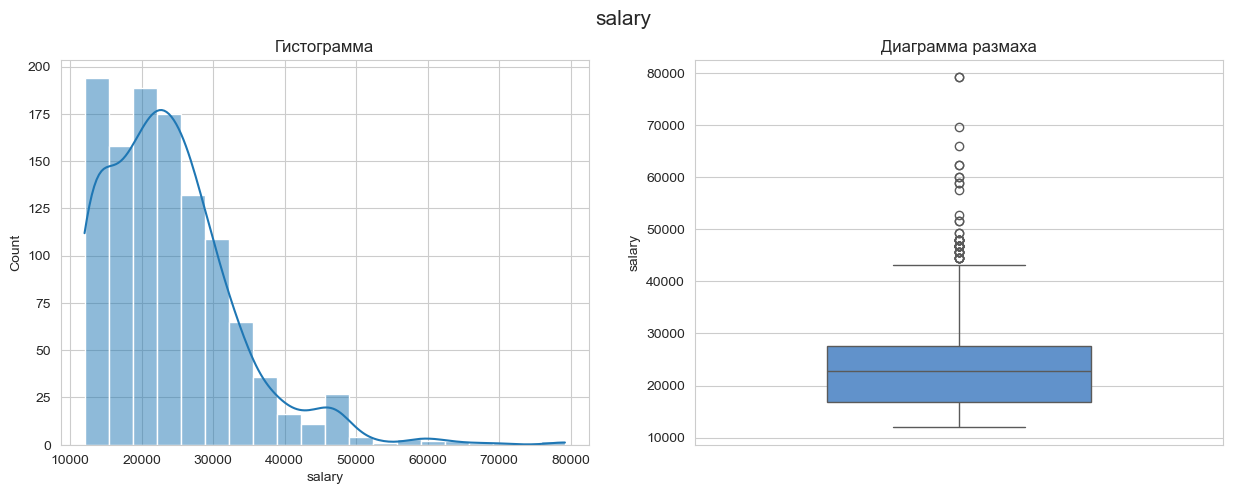

In [82]:
#гистограмма и диаграмма размаха зарплаты уволенных сотрудников
hist_and_boxplot('salary', df_quit_yes)

In [83]:
df_quit_yes['salary'].describe()

count     1128.000000
mean     23885.106383
std       9351.599505
min      12000.000000
25%      16800.000000
50%      22800.000000
75%      27600.000000
max      79200.000000
Name: salary, dtype: float64

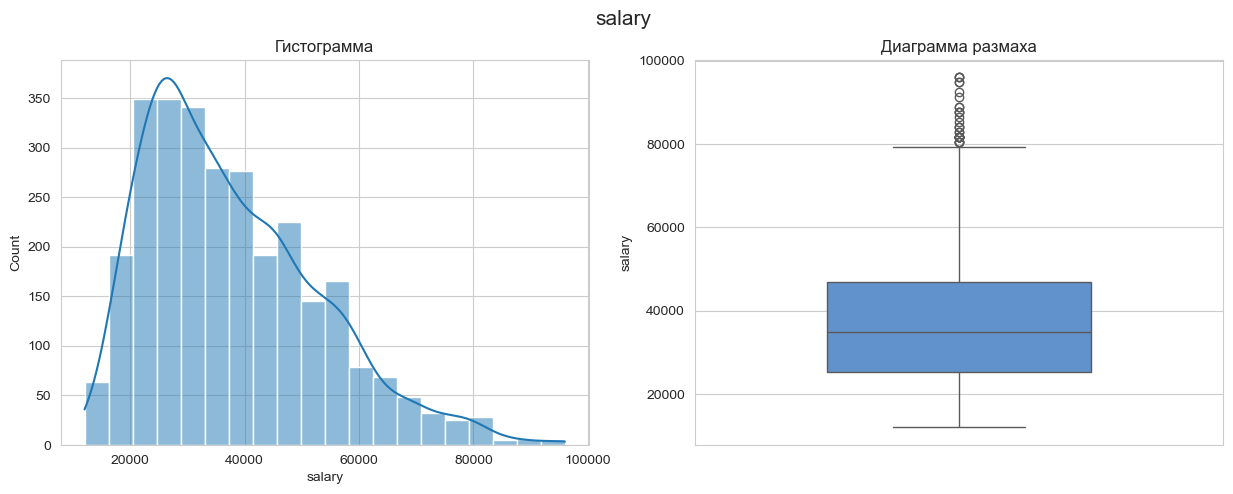

In [84]:
#гистограмма и диаграмма размаха зарплаты действующих сотрудников
hist_and_boxplot('salary', df_quit_no)

In [85]:
df_quit_no['salary'].describe()

count     2872.000000
mean     37702.228412
std      15218.977339
min      12000.000000
25%      25200.000000
50%      34800.000000
75%      46800.000000
max      96000.000000
Name: salary, dtype: float64

У сотрудников, покинувших компанию, зарплата в среднем ниже: около 23.9 тысяч против 37.7 тысяч у оставшихся сотрудников. Медианные значения составляют соответственно 22.8 тысяч и 34.8 тысяч. У 75% покинувших компанию зарплата не превышает 27.6 тысяч.

Таким образом, **повышенная доля увольнений в данной выборке характерна** для следующих групп сотрудников:
* специалисты уровня `junior`;
* сотрудники с небольшим стажем работы, особенно около 1 года и в целом до 3 лет;
* сотрудники с низкой рабочей нагрузкой;
* сотрудники с относительно невысокой зарплатой;
* сотрудники, не получавшие повышения за последний год;
* сотрудники, имевшие нарушения трудового договора;
* сотрудники с более низкими оценками руководителя - прежде всего 1-3.

Эти характеристики описывают статистические различия между группами сотрудников и не означают, что каждый из перечисленных факторов причинно приводит к увольнению.

#### Распределения признака `job_satisfaction_rate`

Визуализируем и сравним распределения признака `job_satisfaction_rate` для ушедших и оставшихся сотрудников. Для этого используем данные с обоими целевыми признаками тестовой выборки.

In [86]:
print(f'Размер df_test_target: {df_test_target.shape}')
df_test_target.head()

Размер df_test_target: (2000, 2)


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


In [87]:
print(f'Размер df_test_quit: {df_test_quit.shape}')
df_test_quit.head()

Размер df_test_quit: (2000, 2)


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


Объеденим целевые выборки по `id` и проверим размер полученного датафрейма.

In [88]:
job_rate_quit = df_test_quit.merge(df_test_target, on='id', how='inner', validate='one_to_one')

print(f'Размер job_rate_quit: {job_rate_quit.shape}')
job_rate_quit.head()

Размер job_rate_quit: (2000, 3)


,id,quit,job_satisfaction_rate
0,999029,yes,0.35
1,372846,no,0.21
2,726767,no,0.73
3,490105,no,0.62
4,416898,yes,0.57


Разделим данные на две подвыборки: уволенные и неуволенные сотрудники.

In [89]:
job_rate_quit_yes = job_rate_quit[job_rate_quit['quit'] == 'yes']
job_rate_quit_no = job_rate_quit[job_rate_quit['quit'] == 'no']

In [90]:
print(f'Количество уволенных сотрудников {len(job_rate_quit_yes)}')
print(f'Количество неуволенных сотрудников {len(job_rate_quit_no)}')

Количество уволенных сотрудников 564
Количество неуволенных сотрудников 1436


Размеры подвыборок сильно отличаются поэтому построим гистограмму плотности распределения для двух подвыборок.  

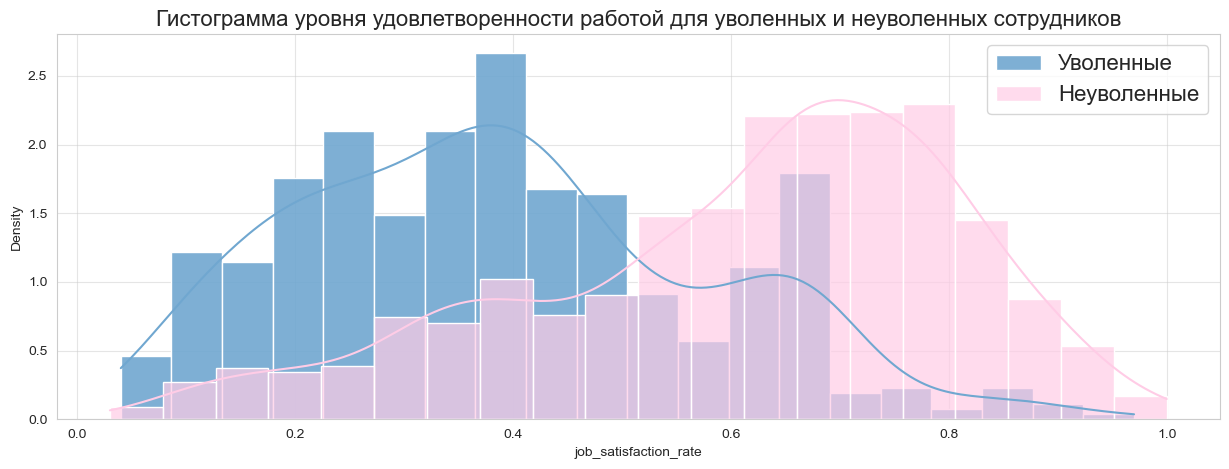

In [91]:
plt.figure(figsize=(15, 5))
sns.histplot(data=job_rate_quit_yes, x='job_satisfaction_rate', label='Уволенные', alpha=0.9, color='#70a7d0', ec='white', \
                 bins=20, kde=True, stat='density', common_norm=False)
sns.histplot(data=job_rate_quit_no,x='job_satisfaction_rate', label='Неуволенные', alpha=0.7, color='#ffcce6', ec='white', \
                 bins=20, kde=True, stat='density', common_norm=False)
plt.title('Гистограмма уровня удовлетворенности работой для уволенных и неуволенных сотрудников', fontsize=16)
plt.legend(loc='upper right', fontsize=16)
plt.grid(alpha=0.5)
plt.show(close=None, block=None)

Видно, что для уволенных сотрудников среднее значение уровня удовлетворенности ниже, чем для действующих сотрудников. Таким образом, уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник.

Выдвинем нулевую и альтернативную гипотезы:

**Нулевая гипотеза:** средние значение уровня удовлетворенности для уволенных и неуволенных сотрудников равны.

**Альтернативная гипотеза:** среднее значение уровня удовлетворенности для неуволенных сотрудников больше среднего значения уровня удовлетворенности для уволенных.

In [92]:
alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

results = st.ttest_ind(job_rate_quit_no['job_satisfaction_rate'], job_rate_quit_yes['job_satisfaction_rate'], equal_var=False, alternative='greater') 

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 1.385431401577187e-101
Отвергаем нулевую гипотезу


Полученное `p-value` значительно меньше уровня значимости 0.05, поэтому нулевая гипотеза о равенстве средних отвергается. Есть основания говорить, что среднее значение уровня удовлетворенности для неуволенных сотрудников больше.

**Выводы**: анализ долей увольнений внутри отдельных категорий показал, что повышенная частота увольнений в данной выборке наблюдается среди сотрудников уровня `junior`, сотрудников с небольшим стажем, низкой рабочей нагрузкой, без повышения за последний год, с нарушениями трудового договора и более низкими оценками руководителя. Кроме того, сотрудники, покинувшие компанию, в среднем имеют более низкую зарплату.

Дополнительный анализ показывает статистическую связь между уровнем удовлетворённости работой и фактом увольнения: у сотрудников, покинувших компанию, распределение `job_satisfaction_rate` смещено в сторону более низких значений.

### Корреляционный анализ данных

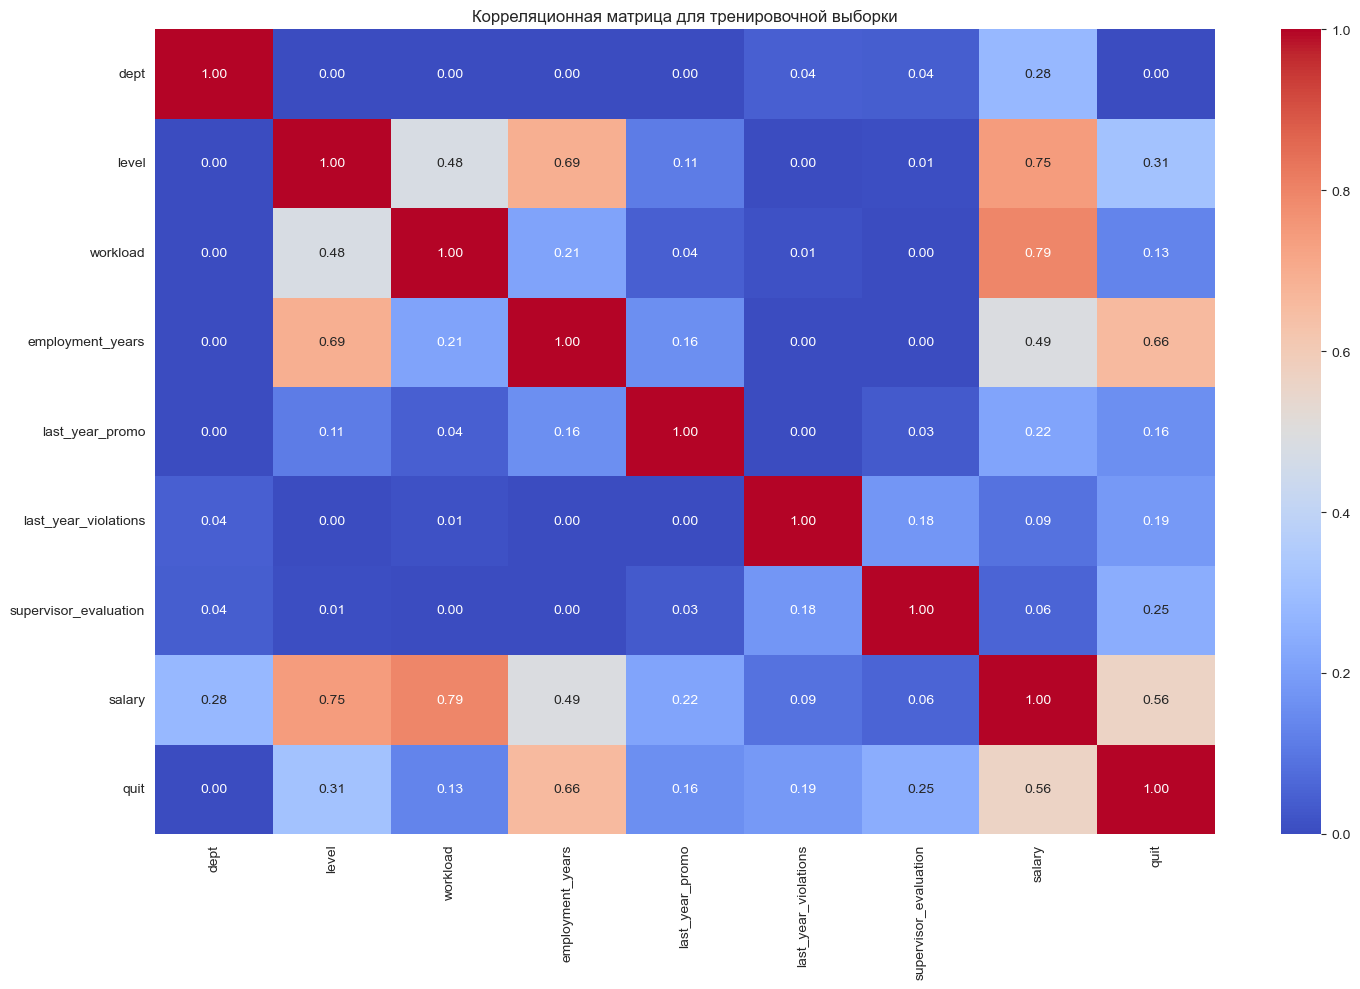

In [93]:
interval_cols = ['salary']

phik_corr = df_quit.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для тренировочной выборки")
plt.tight_layout()
plt.show()

Наиболее выраженные связи `quit` наблюдаются с `employment_years` и `salary`. Среди входных признаков заметны взаимосвязи `salary` с `level`, `workload` и другими характеристиками сотрудника.

Аналогично проведем анализ корреляции для тестовой выборки. Объединим тестовые данные по `id` и проверим размер полученной выборки.

In [94]:
df_test_2= df_test_features_2.merge(df_test_quit, on='id', how='inner', validate='one_to_one')
print(f'Размер df_test_2: {df_test_2.shape}')
df_test_2.head()

Размер df_test_2: (2000, 10)


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,no
1,686555,hr,junior,medium,1,no,no,4,30000,no
2,467458,sales,middle,low,5,no,no,4,19200,no
3,418655,sales,middle,low,6,no,no,4,19200,no
4,789145,hr,middle,medium,5,no,no,5,40800,no


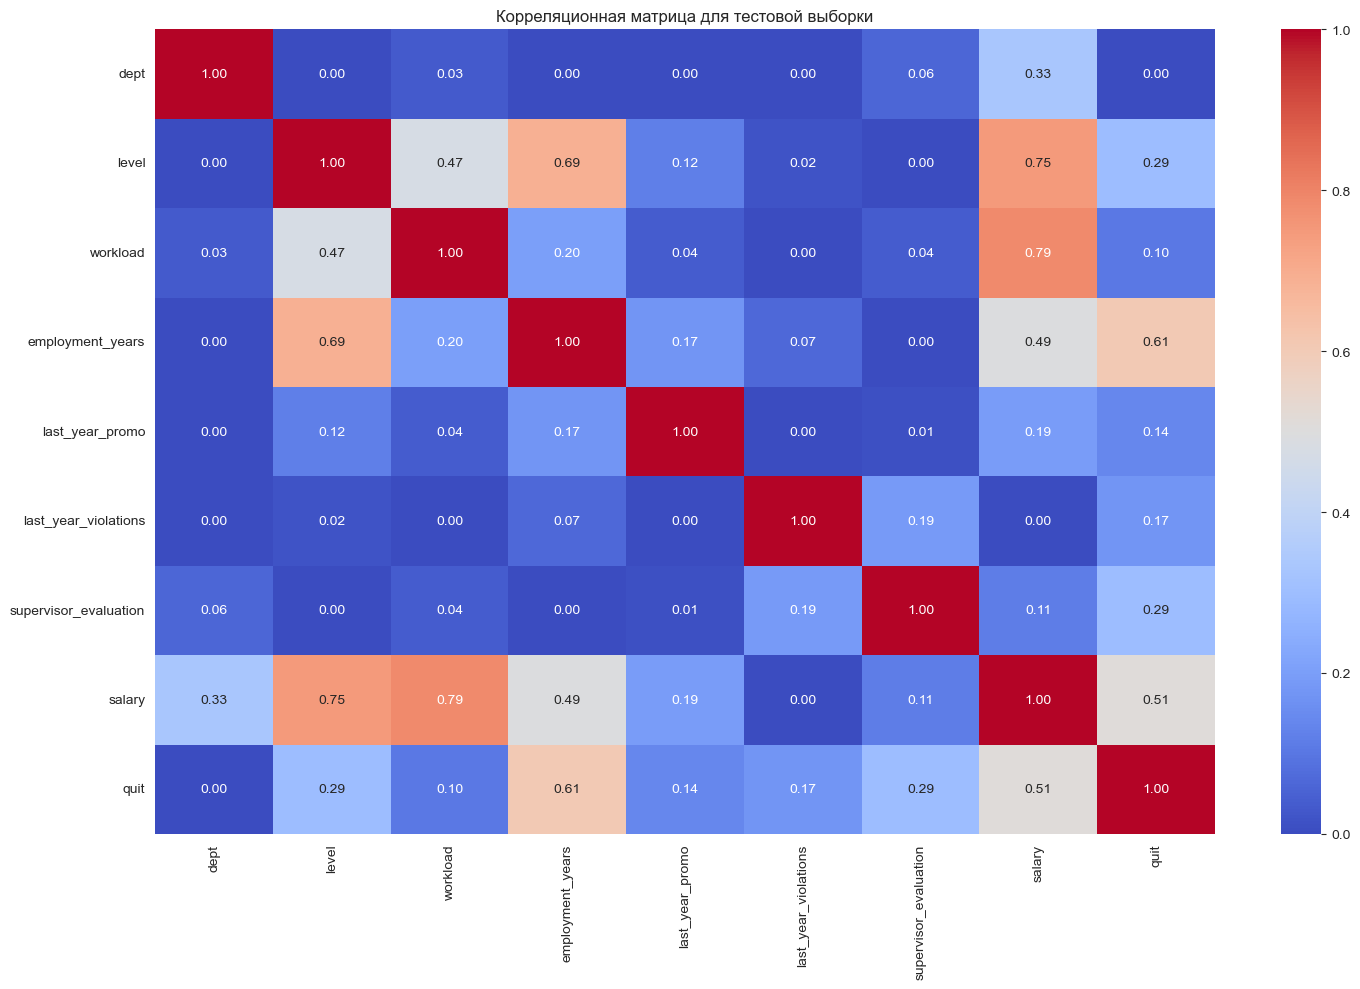

In [95]:
phik_corr = df_test_2.drop('id', axis=1).phik_matrix(interval_cols = ['salary'])
plt.figure(figsize=(15, 10))
sns.heatmap(phik_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для тестовой выборки")
plt.tight_layout()
plt.show()

Корреляционная матрица тренировочной выборки практически идентична исходной. Взаимосвязь между признаками сохраняется.

**Выводы:**
* Наблюдается средняя связь между целевым признаком **quit** и признаками **employment_years** и **salary**;
  
* Видна сильная корреляция между **salary** и **dept**, **level**, **workload**. Несмотря на высокую корреляцию между входными признаками, оставим их, т.к. они отражают разные аспекты работы и их взаимосвязь логична с точки зрения бизнес-процессов. 

### Добавление нового входного признака

In [96]:
train_id_overlap = set(df_train_copy['id']) & set(df_quit['id'])

print('Количество общих id в обучающих выборках двух задач:', len(train_id_overlap))

Количество общих id в обучающих выборках двух задач: 0


Обучающие выборки двух задач не пересекаются по `id`. Поэтому прогноз `job_satisfaction_rate` для второй задачи формируется моделью первой задачи на сотрудниках, которых она не использовала при обучении. Это позволяет избежать утечки информации при создании нового признака.

Добавим `job_satisfaction_rate`, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

In [97]:
# для тренировочной выборки
print(f'Размер df_quit до добавления признака: {df_quit.shape}')
df_quit['job_satisfaction_rate'] = randomized_search.predict(df_quit.drop('quit', axis=1))
print(f'Размер df_quit после добавления признака: {df_quit.shape}')

Размер df_quit до добавления признака: (4000, 10)
Размер df_quit после добавления признака: (4000, 11)


In [98]:
df_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.635385
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.846364
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.340000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


In [99]:
# для тестовой выборки
print(f'Размер df_test_features до добавления признака: {df_test_features_2.shape}')
df_test_features_2['job_satisfaction_rate'] = randomized_search.predict(df_test_features_2)
print(f'Размер df_test_features после добавления признака: {df_test_features_2.shape}')

Размер df_test_features до добавления признака: (2000, 9)
Размер df_test_features после добавления признака: (2000, 10)


In [100]:
df_test_features_2.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.855000
1,686555,hr,junior,medium,1,no,no,4,30000,0.664516
2,467458,sales,middle,low,5,no,no,4,19200,0.654000
3,418655,sales,middle,low,6,no,no,4,19200,0.655000
4,789145,hr,middle,medium,5,no,no,5,40800,0.825306


После того как мы добавили **job_satisfaction_rate**, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи, снова посмотрим как коррелируют новый и исходные признаки в тестовой и тренировочной выборке.

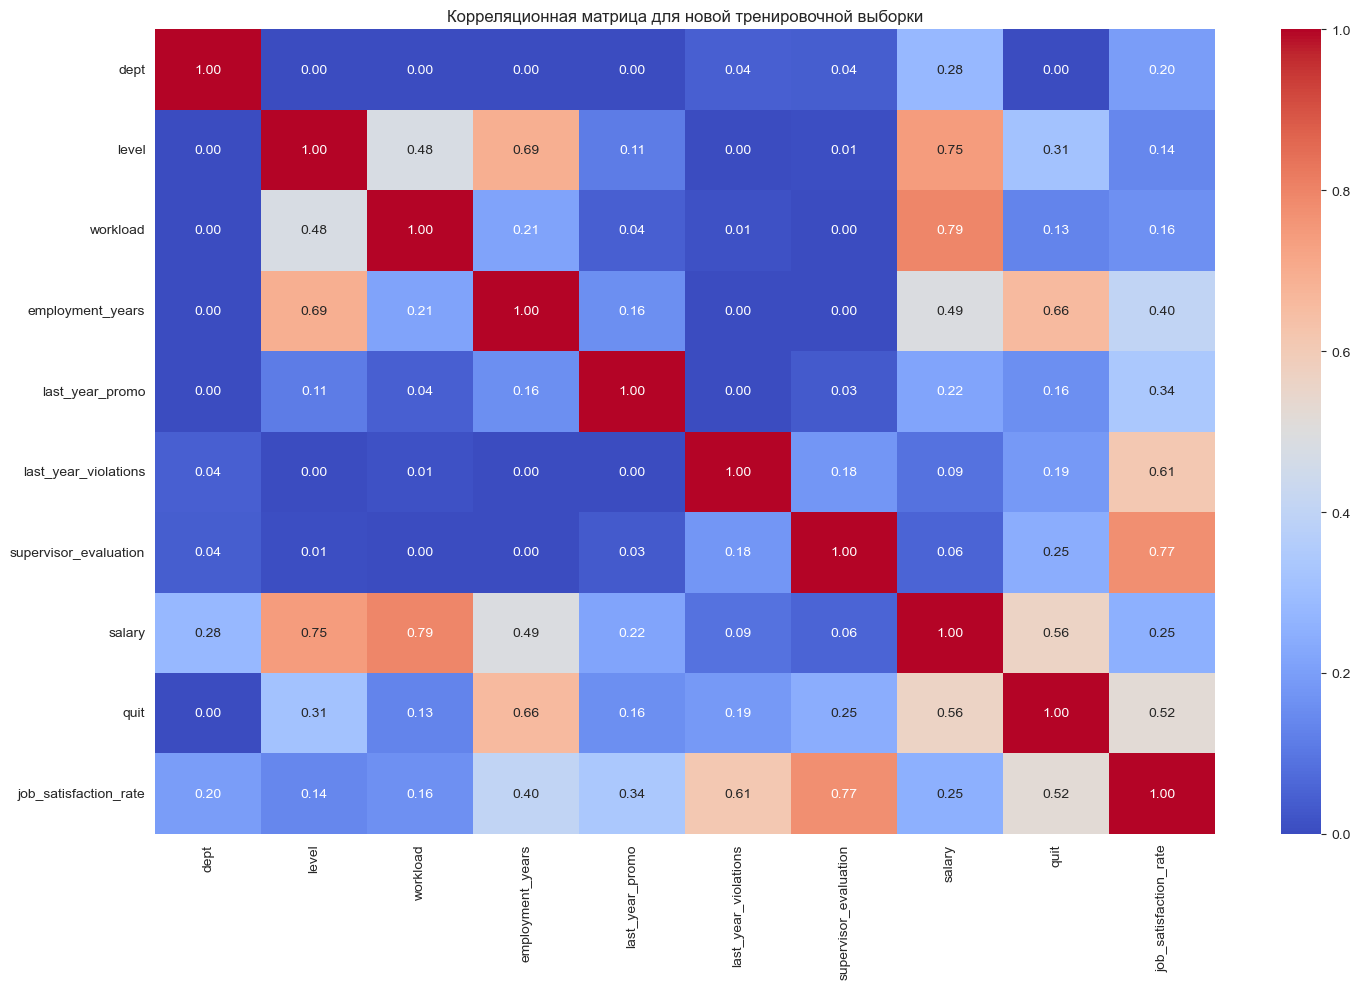

In [101]:
interval_cols_2= df_quit[['salary', 'job_satisfaction_rate']]
phik_matrix = df_quit.drop('id', axis=1).phik_matrix(interval_cols=interval_cols_2)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для новой тренировочной выборки")
plt.tight_layout()
plt.show()

При добавлении нового признака взаимосвязь между исходными признаками практически не поменялась - наиболее выраженные связи `quit` наблюдаются с `employment_years`, `salary` и новым признаком `job_satisfaction_rate`. 


In [102]:
df_test_2= df_test_features_2.merge(df_test_quit, on='id', how='left')
print(f'Размер df_test_2: {df_test_2.shape}')
df_test_2.head()

Размер df_test_2: (2000, 11)


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.855000,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.664516,no
2,467458,sales,middle,low,5,no,no,4,19200,0.654000,no
3,418655,sales,middle,low,6,no,no,4,19200,0.655000,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.825306,no


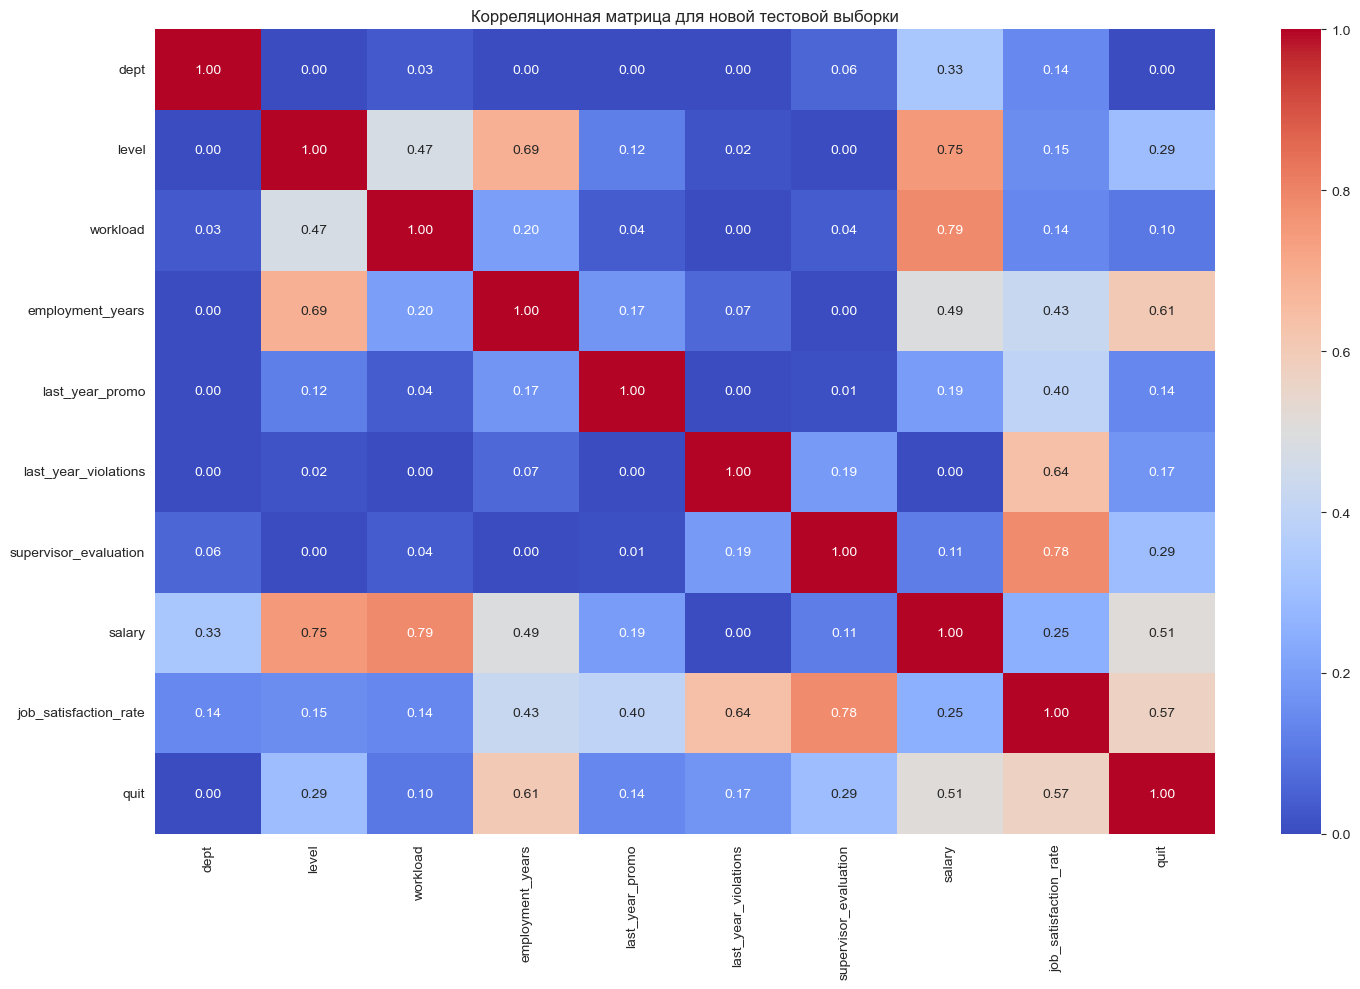

In [103]:
interval_cols_test_2= df_test_2[['salary', 'job_satisfaction_rate']]
phik_matrix = df_test_2.drop('id', axis=1).phik_matrix(interval_cols=interval_cols_test_2)
plt.figure(figsize=(15, 10))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица для новой тестовой выборки")
plt.tight_layout()
plt.show()

По сути, корреляционная матрица тестовой выборки почти такая же, как и для тренировочной, связи между признаками не изменились.

**Вывод:** 
Прогнозируемый уровень удовлетворённости имеет связь с целевой переменной `quit`. При этом `job_satisfaction_rate` является производным от исходных характеристик сотрудников, поэтому его полезность для второй модели необходимо оценить по качеству на кросс-валидации.

### Подготовка данных

Для удобства работы с данными установим колонку `id` в качестве индекса датафрейма и создадим пайплайн для подготовки данных

In [104]:
# устанавливаем столбец 'id' в качестве индекса
df_quit = df_quit.set_index('id')
df_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
id,,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no,0.635385
814010,sales,junior,medium,2,no,no,4,27600,no,0.846364
155091,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
257132,sales,junior,medium,2,no,yes,3,24000,yes,0.340000
910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


In [105]:
print(f'В тренировочной выборке {df_quit.duplicated().sum()} дубликатов') 
print(f'Доля дубликатов в тренировочной выборке: {(df_quit.duplicated().sum()/len(df_quit)).round(2)}') 
df_quit = df_quit.drop_duplicates(keep='first')
print(f'В тренировочной выборке стало {df_quit.duplicated().sum()} дубликатов') 
print(f'Длина датафрейма после удаления части данных стала {len(df_quit)}')

В тренировочной выборке 1413 дубликатов
Доля дубликатов в тренировочной выборке: 0.35
В тренировочной выборке стало 0 дубликатов
Длина датафрейма после удаления части данных стала 2587


In [106]:
# определяем целевой и входные признаки для тренировочной и тестовой выборки
X_train_2 = df_quit.drop(['quit'], axis=1)
y_train_2 = df_quit['quit']
X_test_2 = df_test_2.drop(['quit'], axis=1)
y_test_2 = df_test_2['quit']

In [107]:
# создаем LabelEncoder для целевой переменной
label_encoder = LabelEncoder()
label_encoder.fit(y_train_2)

# задаем нужный порядок классов
label_encoder.classes_ = np.array(['no', 'yes']) # 'no' -> 0, 'yes' -> 1

# кодируем данные
y_train_encoded = label_encoder.transform(y_train_2)
y_test_encoded = label_encoder.transform(y_test_2)

In [108]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level','workload']
num_columns = ['employment_years', 'salary', 'supervisor_evaluation', 'job_satisfaction_rate']

In [109]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ]
)

In [110]:
# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(categories=[
                               ['junior', 'middle', 'senior'],
                               ['low', 'medium', 'high']
                
                          ],
                          handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [111]:
# создаём общий пайплайн для подготовки данных
data_preprocessor_2= ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

**Вывод**: для второй задачи сформированы входные признаки и бинарная целевая переменная `quit`. Идентификатор `id` используется как индекс. В качестве дополнительного числового признака используется `job_satisfaction_rate` - прогноз модели из первой задачи.

Категориальные признаки разделены на номинальные и порядковые; заполнение пропусков, кодирование категорий и масштабирование числовых признаков выполняются внутри `ColumnTransformer`.

### Обучение модели

In [112]:
# задаем фиксированное значение для random_state
RANDOM_STATE = 42
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final_2 = Pipeline([
    ('preprocessor', data_preprocessor_2),
    ('models', LogisticRegression())
])

In [113]:
param_grid_2 = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 16),
        'models__min_samples_split':range(2,16),
        'models__max_features': range(2, 16),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__C': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    }
] 

In [114]:
randomized_search_2 = RandomizedSearchCV(
    pipe_final_2, 
    param_grid_2, 
    cv=5,
    n_iter=30,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1)

randomized_search_2.fit(X_train_2, y_train_2)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [DecisionTreeC...ndom_state=42)], 'models__max_depth': range(2, 16), 'models__max_features': range(2, 16), 'models__min_samples_split': range(2, 16), ...}, {'models': [LogisticRegre...ndom_state=42)], 'models__C': range(1, 10), 'preprocessor__num': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not

В качестве основной метрики используется `ROC-AUC`, поскольку задача является бинарной классификацией, а классы распределены неравномерно.

In [115]:
print('Лучшая модель и её параметры:\n\n', randomized_search_2.best_estimator_)
print ('Метрика на кросс-валидации:', round(randomized_search_2.best_score_, 2))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                            

Лучшей моделью оказалась DecisionTreeRegressor с max_depth=5, max_features=5 и min_samples_split=5. Проверим метрику на тестовой выборке

In [116]:
test_score = roc_auc_score(y_test_2, randomized_search_2.predict_proba(X_test_2)[:, 1])
round(test_score, 2)

0.91

На тестовой выборке `ROC-AUC` составил 0.91. Проверим модель на адекватность и посчитаем метрику для константной модели `DummyClassifier`.

In [117]:
# создание и обучение модели DummyClassifier 
dummy_model = DummyClassifier(random_state=RANDOM_STATE, strategy='most_frequent')
dummy_model.fit(X_train_2, y_train_2)

# предсказание на тестовых данных
dummy_model_probas = dummy_model.predict_proba(X_test_2)[:,1]

# посчитаем и выведем метрику ROC-AUC
dummy_roc = roc_auc_score(y_test_2, dummy_model_probas)
print('ROC-AUC =', round(dummy_roc,2))

ROC-AUC = 0.5


Получилось, что выбранная лучшая модель лучше константной. Оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP

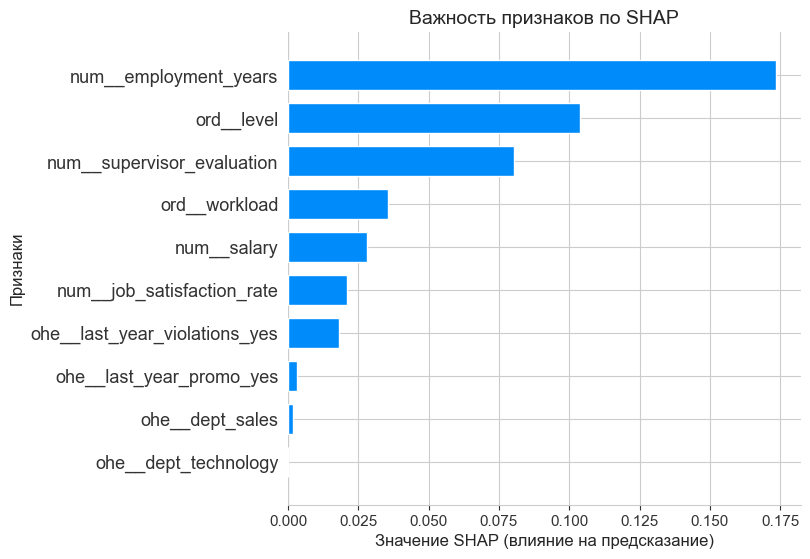

In [118]:
best_pipeline_2 = randomized_search_2.best_estimator_

preprocessor_2 = best_pipeline_2.named_steps['preprocessor']
model_2 = best_pipeline_2.named_steps['models']

X_train_transformed_2 = preprocessor_2.transform(X_train_2)

X_train_shap_2 = pd.DataFrame(
    X_train_transformed_2,
    columns=preprocessor_2.get_feature_names_out(),
    index=X_train_2.index
)


explainer = shap.TreeExplainer(model_2)
shap_values = explainer.shap_values(X_train_shap_2)
shap.summary_plot(shap_values[:,:,1], X_train_shap_2, plot_type="bar", show=False, max_display=10)
plt.xlabel('Значение SHAP (влияние на предсказание)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Важность признаков по SHAP', fontsize=14)
plt.show()

Наибольший вклад в прогноз `DecisionTreeClassifier` вносят следующие признаки:

* уровень занимаемой должности
* уровень удовлетворённости сотрудника работой в компании
* продолжительность работы в компании, измеренная в годах
* уровень занятости сотрудника

**Вывод:** 

* Обучены 3 модели: `KNeighborsClassifier`, `DecisionTreeClassifier`, `LogisticRegression`;

* Для подбора гиперпараметров использовался рандомизированный поиск;

* Для оценки качества моделей выбрана метрика `ROC-AUC`;

В результате метрика `ROC-AUC` достигла 0.91 на тестовой выборке для модели `DecisionTreeClassifier`.

### Выводы

Для прогнозирования увольнения были сравнены `LogisticRegression`, `KNeighborsClassifier` и `DecisionTreeClassifier`. 

Подготовка признаков и подбор гиперпараметров выполнялись внутри единого пайплайна с 5-кратной кросс-валидацией. В качестве основной метрики использовался `ROC-AUC`.

Лучший результат среди рассмотренных конфигураций показал `DecisionTreeClassifier`: средний `ROC-AUC` на кросс-валидации составил 0.90, а на отложенной тестовой выборке - 0.91, что превышает установленный в задаче критерий ROC-AUC > 0.9. Для константного `DummyClassifier` ROC-AUC составил 0.50.

По результатам SHAP-анализа наибольший вклад в прогноз модели вносят уровень должности, прогнозируемый уровень удовлетворённости работой (`job_satisfaction_rate`), стаж и рабочая нагрузка. Эти результаты характеризуют поведение модели и не доказывают причинного влияния признаков на увольнение.

## Общий вывод

**Цель проекта - построить две модели машинного обучения для HR-аналитики:**

1. прогнозирование уровня удовлетворённости сотрудника работой;
2. прогнозирование увольнения сотрудника из компании.

Дополнительно исследовалось, может ли прогноз удовлетворённости из первой задачи использоваться как дополнительный признак во второй задаче.

### Задача 1. Прогнозирование уровня удовлетворённости

#### Подготовка и исследование данных

Были загружены обучающая выборка, тестовые признаки и тестовая целевая переменная.

В ходе предобработки:

- исследованы пропуски и дубликаты;
- исправлена опечатка `sinior - senior`;
- строки, состоящие из пробелов, приведены к пропущенным значениям;
- `id` использовался только как индекс и не передавался модели;
- заполнение пропусков и кодирование категориальных признаков выполнялись внутри пайплайна.

Исследовательский анализ показал, что сотрудники представлены пятью подразделениями, среди уровней должности преобладают `junior` и `middle`, а наиболее распространён средний уровень рабочей нагрузки.

Стаж сотрудников составляет от 1 до 10 лет. Медианная зарплата - 30 тысяч, распределение зарплаты имеет правую асимметрию.

Целевая переменная `job_satisfaction_rate` принимает значения от 0.03 до 1.00, медиана составляет 0.56.

По матрице корреляций наиболее выраженная связь уровня удовлетворённости наблюдается с `supervisor_evaluation`; также обнаружены связи с рядом других характеристик сотрудника. Эти зависимости рассматриваются как статистические и не интерпретируются как причинные.

#### Моделирование

Для прогнозирования `job_satisfaction_rate` были сравнены:

* `LinearRegression`;
* `DecisionTreeRegressor`.

Предобработка и подбор гиперпараметров выполнялись внутри единого пайплайна с 5-кратной кросс-валидацией. Основная метрика — SMAPE.

Лучшей среди рассмотренных конфигураций стала модель `DecisionTreeRegressor`.

Результаты:

* **CV SMAPE — 15.37%**;
* **Test SMAPE — 14.09%**;
* `DummyRegressor` — **38.26%**.

Таким образом, модель выполнила установленное в задаче требование `SMAPE ≤ 15%` на отложенной тестовой выборке и существенно превзошла константный baseline.

По результатам SHAP-анализа наибольший вклад в прогноз модели вносят:

* оценка сотрудника руководителем (`supervisor_evaluation`);
* стаж работы (`employment_years`);
* уровень должности (`level`);
* размер заработной платы (`salary`).


### Задача 2. Прогнозирование увольнения

#### Подготовка и исследование данных

Во второй задаче используется тот же набор исходных характеристик сотрудников, но целевой переменной является бинарный признак `quit`.

Доля сотрудников, покинувших компанию, составляет около 28%, поэтому классы распределены неравномерно.

Анализ доли увольнений внутри отдельных категорий показал, что в данной выборке более высокая частота увольнений наблюдается:

* среди сотрудников уровня `junior`;
* среди сотрудников с небольшим стажем, особенно около одного года;
* при низкой рабочей нагрузке;
* среди сотрудников, не получивших повышение за последний год;
* среди сотрудников с нарушениями трудового договора;
* при более низких значениях оценки руководителя.

Кроме того, сотрудники, покинувшие компанию, в среднем имеют более низкую зарплату.

Эти результаты описывают статистические различия между группами и не означают причинного влияния отдельных характеристик на увольнение.

#### Дополнительный признак удовлетворённости

Для второй задачи был сформирован новый признак: `job_satisfaction_rate` - прогноз уровня удовлетворённости, полученный лучшей моделью первой задачи.

Перед его созданием было проверено, что обучающие выборки двух задач **не пересекаются по `id`**. Поэтому прогноз удовлетворённости для сотрудников второй задачи формируется моделью, которая не использовала этих сотрудников при обучении.

Это позволяет использовать прогноз первой модели как дополнительный признак без утечки информации через совпадающие наблюдения.

#### Моделирование

Для прогнозирования `quit` были сравнены:

* `LogisticRegression`;
* `KNeighborsClassifier`;
* `DecisionTreeClassifier`.

Подбор гиперпараметров выполнялся с помощью `RandomizedSearchCV` и 5-кратной кросс-валидации.

В качестве основной метрики использовался `ROC-AUC`, поскольку задача является бинарной классификацией, а классы распределены неравномерно.

Лучшей среди рассмотренных конфигураций стала модель `DecisionTreeClassifier`.

Результаты:

* **CV ROC-AUC - 0.90**;
* **Test ROC-AUC - 0.91**;
* `DummyClassifier` - **0.50**.

Таким образом, выбранная модель превысила установленный в задаче критерий `ROC-AUC > 0.9` на отложенной тестовой выборке и существенно превзошла константный baseline.

По результатам SHAP-анализа наибольший вклад в прогноз модели вносят:

* уровень должности (`level`);
* прогнозируемый уровень удовлетворённости (`job_satisfaction_rate`);
* стаж работы (`employment_years`);
* уровень рабочей нагрузки (`workload`).

Важно, что `job_satisfaction_rate` является прогнозом первой модели, а не фактически измеренным значением удовлетворённости.


### Итог

В рамках проекта построены две связанные модели машинного обучения:

* `DecisionTreeRegressor` для прогнозирования удовлетворённости сотрудников - **SMAPE = 14.09%** на тестовой выборке;
- `DecisionTreeClassifier` для прогнозирования увольнения - **ROC-AUC = 0.91** на тестовой выборке.

Обе модели выполнили установленные в задачах критерии качества и превзошли соответствующие константные baseline.

Проект также демонстрирует каскадный подход: прогноз первой модели используется как дополнительный признак для второй задачи. При формировании этого признака проверено отсутствие пересечения сотрудников между обучающими выборками двух задач.

Полученные результаты показывают статистические взаимосвязи между характеристиками сотрудников, удовлетворённостью работой и увольнением. Однако offline-анализ не позволяет интерпретировать эти связи как доказанные причинно-следственные зависимости.


### Возможные направления практического применения

Полученные модели могут использоваться как дополнительный инструмент HR-аналитики для выявления групп сотрудников, которым может потребоваться дополнительное внимание.

На основании обнаруженных связей можно сформулировать гипотезы для дальнейшей проверки, например:

- исследовать причины повышенной частоты увольнений среди сотрудников уровня `junior` и сотрудников с небольшим стажем;
- проверить эффективность программ адаптации и развития новых сотрудников;
- исследовать конкурентоспособность компенсации для групп с повышенной частотой увольнений;
- анализировать связь карьерного продвижения, обратной связи руководителей и удержания сотрудников;
- использовать прогноз модели как дополнительный сигнал для HR-аналитика, а не как основание для автоматических кадровых решений.

Перед практическим использованием моделей необходимо проверить их качество на новых данных, стабильность во времени и возможные различия качества между группами сотрудников.